## Notebook de analise de metricas de saida dos modelos treinados

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch -q

In [2]:
import pandas as pd
import sys
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt


In [3]:
## Read files 
df1_pred = np.float32(np.load('../saida_4000-augumented/saidas/output/metricas/train/fold_0/predict_label_train_fold_0.npy', allow_pickle=True))
df1_true = np.float32(np.load('../saida_4000-augumented/saidas/output/metricas/train/fold_0/true_label_train_fold_0.npy', allow_pickle=True))

In [20]:
path = 'dataset_AFIB_Others/data/'


In [5]:
def calc_loss(outputs, labels):
    criterio = nn.CrossEntropyLoss()
    acc = []
    for i in range(len(outputs)):
        #print(f'Size of output {i}: {outputs[i].shape}, Size of label {i}: {labels[i].shape}')
        loss = criterio(outputs[i], labels[i])
        acc.append(loss.item())
        #print(f'Loss for sample {i}: {loss.item()}')
    return sum(acc) / len(acc)


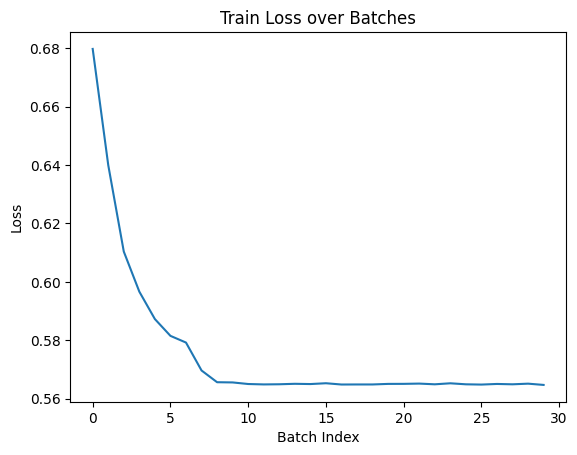

In [6]:
criterio = nn.BCEWithLogitsLoss()
total_loss = []
for i in range(len(df1_pred)):
    outputs_tensor = torch.tensor(df1_pred[i]).to(torch.float)
    labels_tensor = torch.tensor(df1_true[i]).to(torch.float)
    #print(outputs_tensor.shape, labels_tensor.shape)
    loss = criterio(outputs_tensor, labels_tensor)
    #loss = calc_loss(outputs_tensor, labels_tensor)
    total_loss.append(loss)
    #print(f'Loss for batch {i}: {loss}')
plt.plot(total_loss)
plt.title('Train Loss over Batches')
plt.xlabel('Batch Index')
plt.ylabel('Loss')
plt.show()

## Loop to print all train

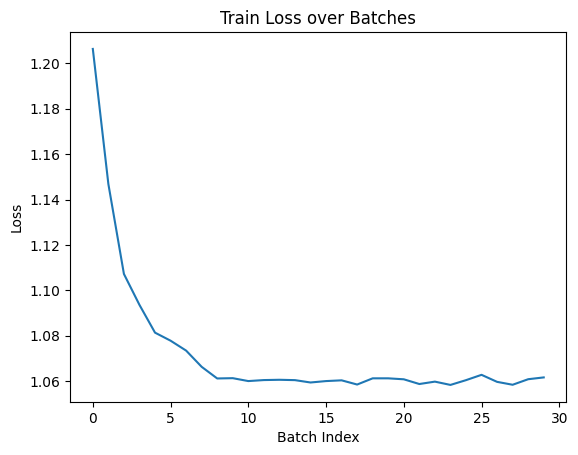

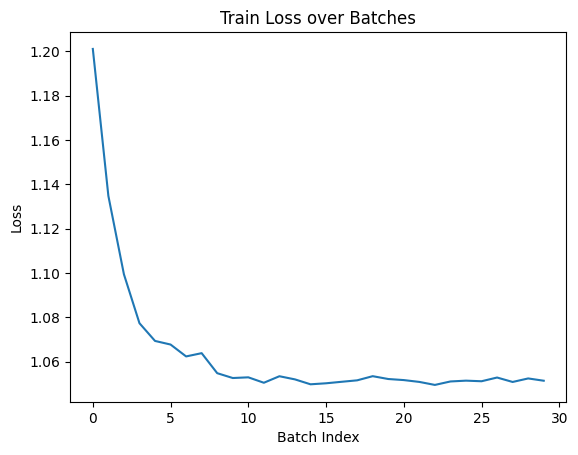

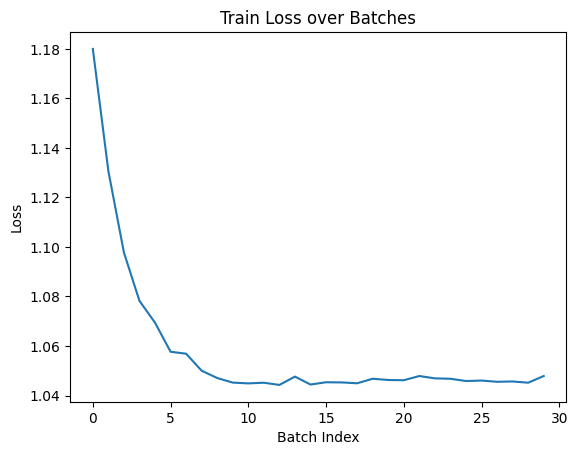

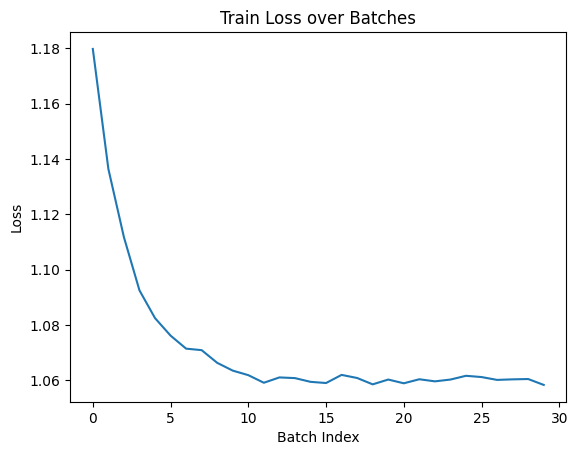

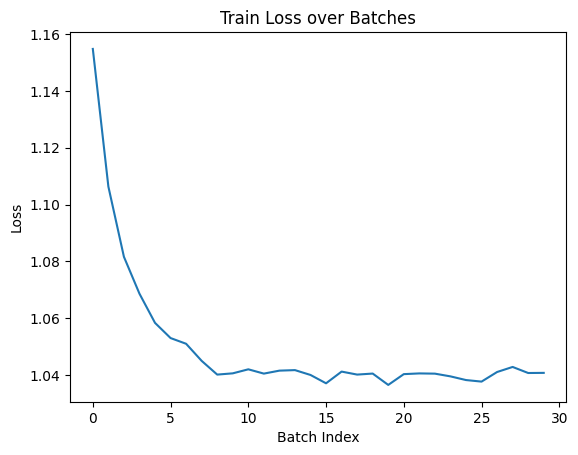

In [7]:
## Read files 
N_fold = 5

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))
    criterio = nn.CrossEntropyLoss()
    total_loss = []
    for j in range(len(df1_pred)):
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        #print(outputs_tensor.shape, labels_tensor.shape)
        #loss = criterio(outputs_tensor, labels_tensor)
        loss = calc_loss(outputs_tensor, labels_tensor)/len(df1_pred)
        total_loss.append(loss)
        #print(f'Loss for batch {i}: {loss}')
    plt.plot(total_loss)
    plt.title('Train Loss over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.show()

In [8]:
## Calculo precisao, recall e f1 score
from sklearn.metrics import precision_score, recall_score, f1_score
for i in range(len(df1_pred)):
    outputs_tensor = torch.tensor(df1_pred[i]).to(torch.float)
    labels_tensor = torch.tensor(df1_true[i]).to(torch.float)
    
    # Convertir las predicciones a etiquetas binarias (0 o 1) usando un umbral de 0.5
    predicted_labels = (outputs_tensor > 0.5).int().numpy()
    true_labels = labels_tensor.int().numpy()
    
    precision = precision_score(true_labels, predicted_labels, average='micro')
    recall = recall_score(true_labels, predicted_labels, average='micro')
    f1 = f1_score(true_labels, predicted_labels, average='micro')
    

In [9]:
m = nn.Sigmoid()
loss = nn.BCELoss()
input = torch.randn(3, 2, requires_grad=True)
target = torch.rand(3, 2, requires_grad=False)
output = loss(m(input), target)
output

tensor(0.8071, grad_fn=<BinaryCrossEntropyBackward0>)

In [10]:
loss2 = nn.BCEWithLogitsLoss()
output2 = loss2(input, target)
output2

tensor(0.8071, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [11]:
input

tensor([[-0.5138,  0.0399],
        [ 0.0315,  0.9912],
        [-1.0281, -0.0319]], requires_grad=True)

In [12]:
target

tensor([[0.9813, 0.4108],
        [0.3863, 0.2975],
        [0.4521, 0.4986]])

In [13]:
loss2 = nn.BCEWithLogitsLoss()
output2 = loss2(input, target)
output2

tensor(0.8071, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

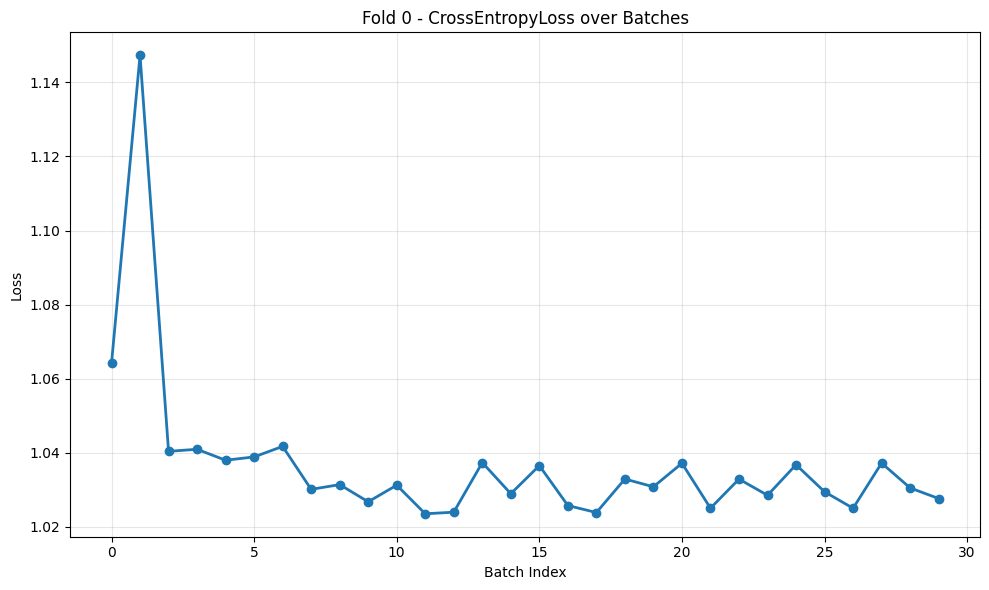

Fold 0 - Mean Loss: 1.036807, Std Loss: 0.021996


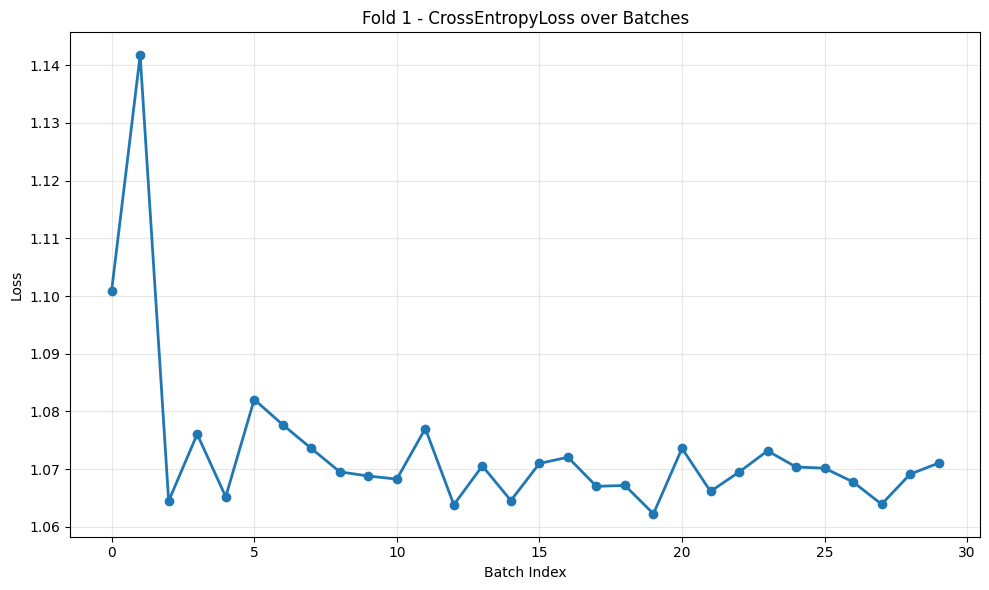

Fold 1 - Mean Loss: 1.073303, Std Loss: 0.014564


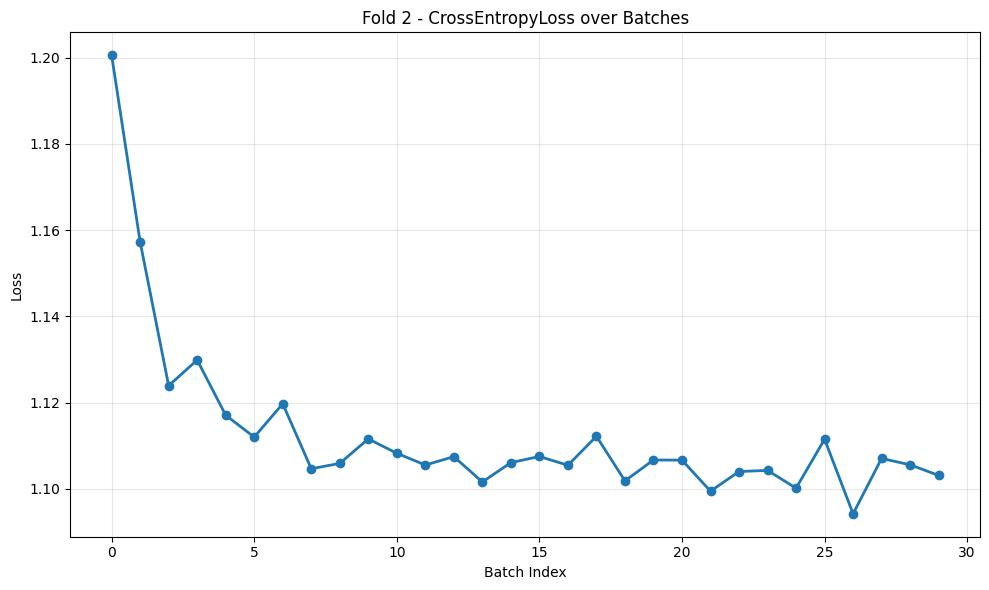

Fold 2 - Mean Loss: 1.112722, Std Loss: 0.019866


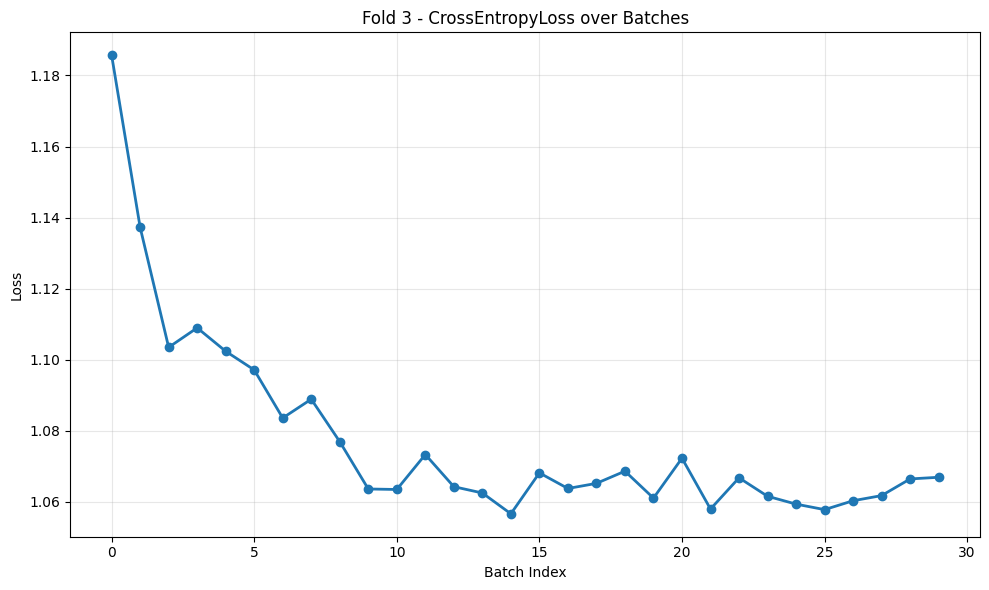

Fold 3 - Mean Loss: 1.077569, Std Loss: 0.027318


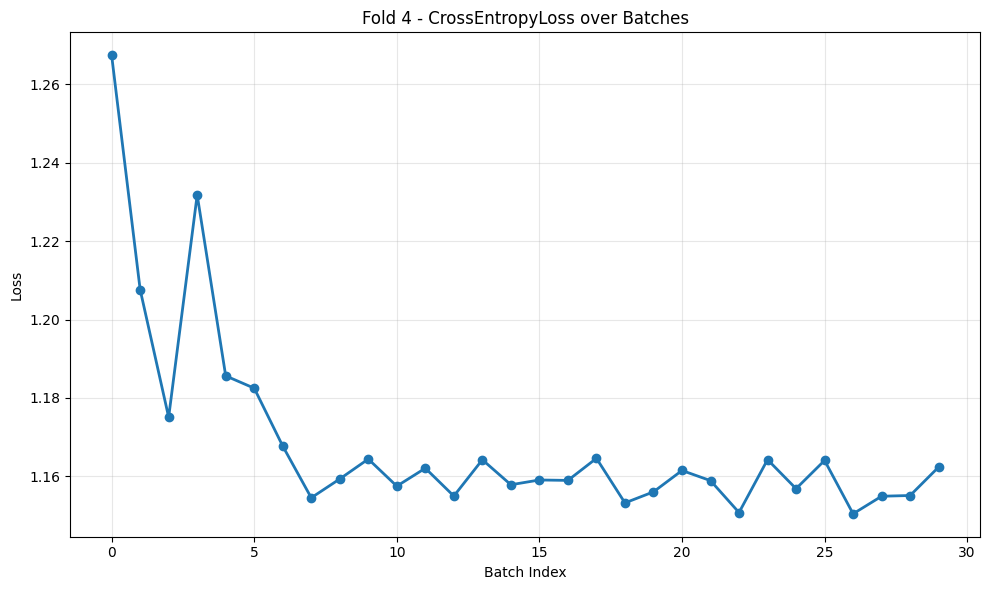

Fold 4 - Mean Loss: 1.168789, Std Loss: 0.024881


In [14]:
## Read files and plot metrics using CrossEntropyLoss
N_fold = 5
criterio = nn.CrossEntropyLoss()

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    total_loss = []
    
    for j in range(len(df1_pred)):
        # Convert predictions to tensor with correct shape for CrossEntropyLoss
        # df1_pred[j] should be (batch_size, num_classes)
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        
        # Convert labels to long integers for CrossEntropyLoss
        # df1_true[j] should be (batch_size,)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        

        # = torch.argmax(outputs_tensor, dim=1)  # Get predicted class indices
        #print(f"Batch {j}: outputs shape={outputs_tensor.shape}, labels shape={labels_tensor.shape}")
        
        # Calculate loss using CrossEntropyLoss
        loss = criterio(outputs_tensor, labels_tensor)/len(df1_pred)
        total_loss.append(loss.item())  # Extract scalar value
    
    # Plot loss over batches for this fold
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss, marker='o', linestyle='-', linewidth=2)
    plt.title(f'Fold {i} - CrossEntropyLoss over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Fold {i} - Mean Loss: {np.mean(total_loss):.6f}, Std Loss: {np.std(total_loss):.6f}")


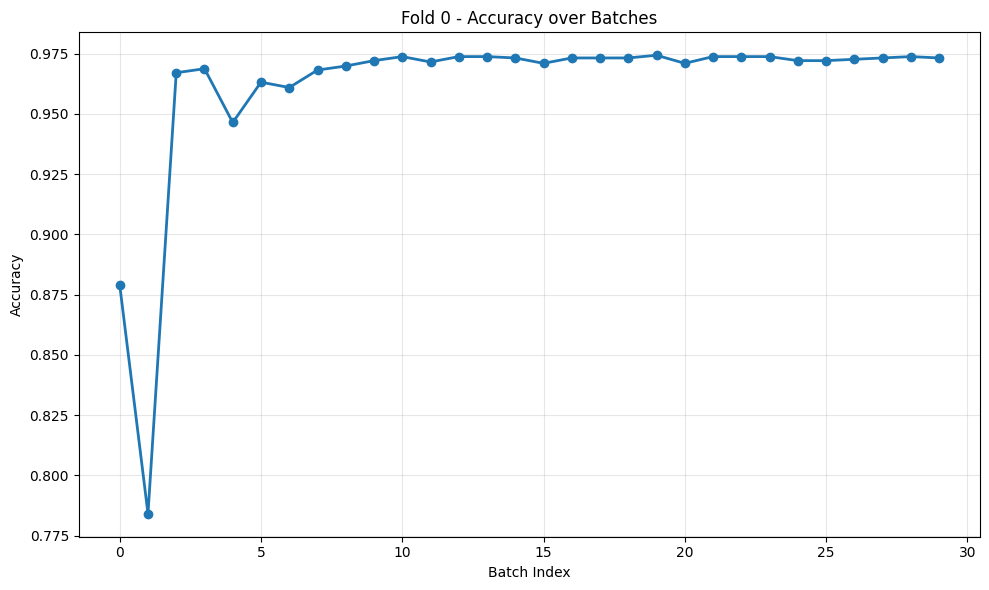

Fold 0 - Mean Accuracy: 0.961328, Std Accuracy: 0.037205


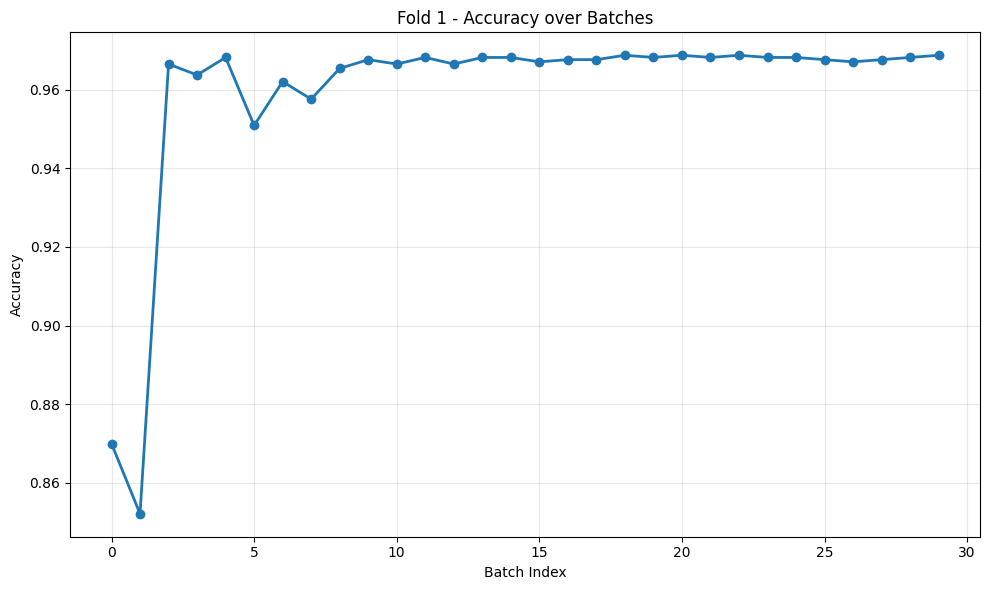

Fold 1 - Mean Accuracy: 0.959412, Std Accuracy: 0.026644


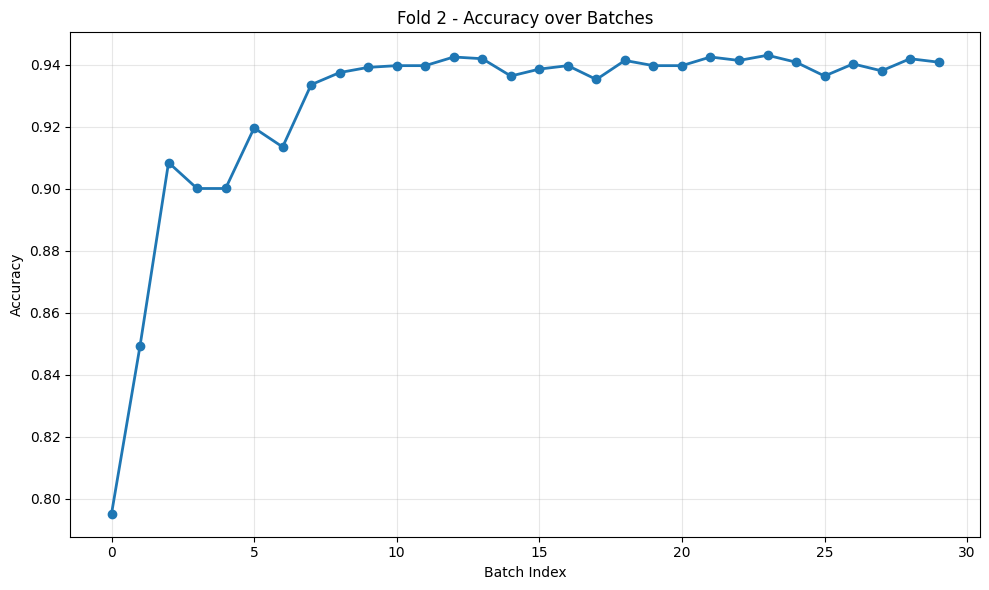

Fold 2 - Mean Accuracy: 0.926562, Std Accuracy: 0.031199


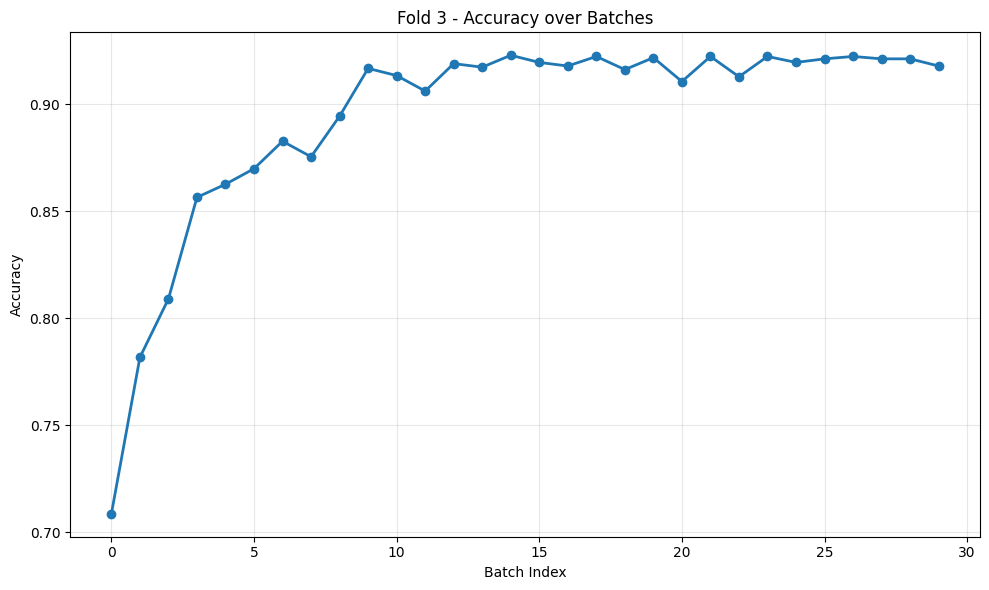

Fold 3 - Mean Accuracy: 0.894289, Std Accuracy: 0.048462


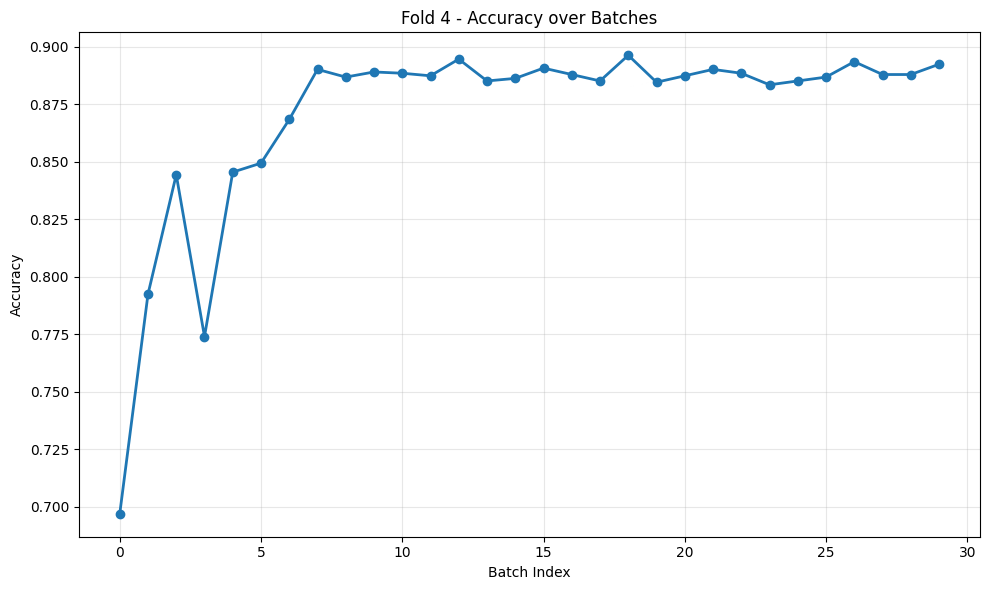

Fold 4 - Mean Accuracy: 0.870145, Std Accuracy: 0.042780


In [18]:
## Read files and plot metrics using CrossEntropyLoss
N_fold = 5
criterio = nn.CrossEntropyLoss()

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    total_loss = []
    
    for j in range(len(df1_pred)):
        # Convert predictions to tensor with correct shape for CrossEntropyLoss
        # df1_pred[j] should be (batch_size, num_classes)
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        
        # Convert labels to long integers for CrossEntropyLoss
        # df1_true[j] should be (batch_size,)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        

        # Calculo Acuracia do modelo
        # Calculate accuracy
        #print(outputs_tensor)
        accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) /len(labels_tensor[-1])
        #print(f"Batch {j}: Accuracy={accuracy:.4f} / {len(labels_tensor[-1])}")
        total_loss.append(accuracy)  # Store accuracy instead of loss
    # Plot loss over batches for this fold
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss, marker='o', linestyle='-', linewidth=2)
    plt.title(f'Fold {i} - Accuracy over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Fold {i} - Mean Accuracy: {np.mean(total_loss):.6f}, Std Accuracy: {np.std(total_loss):.6f}")


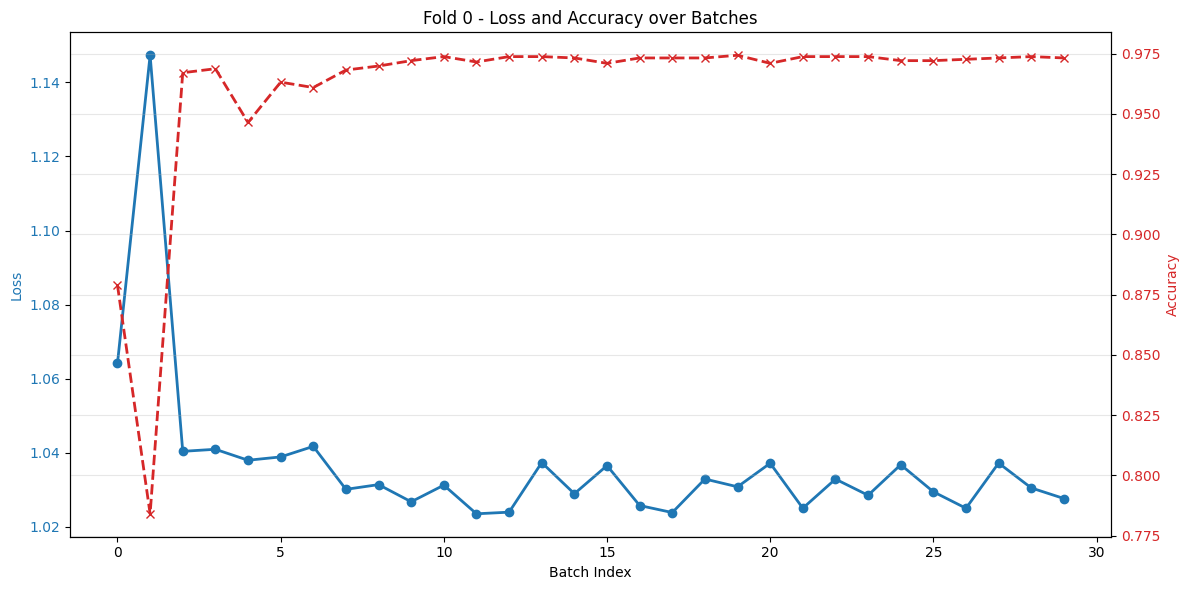

Fold 0 - Mean Loss: 1.036807, Std Loss: 0.021996
Fold 0 - Mean Accuracy: 0.961328, Std Accuracy: 0.037205


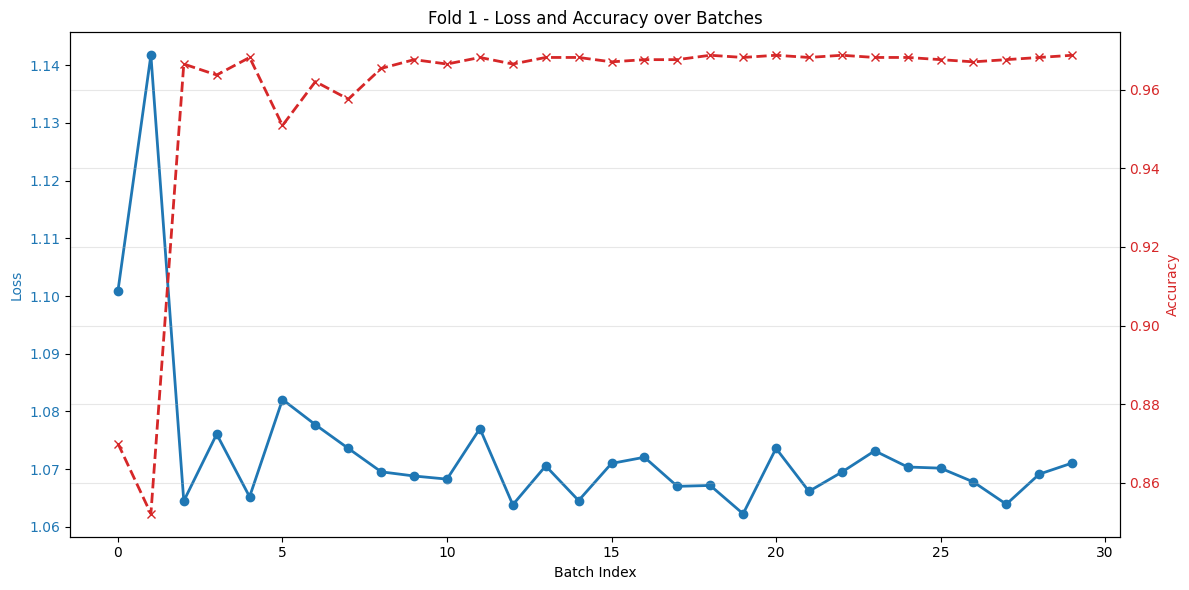

Fold 1 - Mean Loss: 1.073303, Std Loss: 0.014564
Fold 1 - Mean Accuracy: 0.959412, Std Accuracy: 0.026644


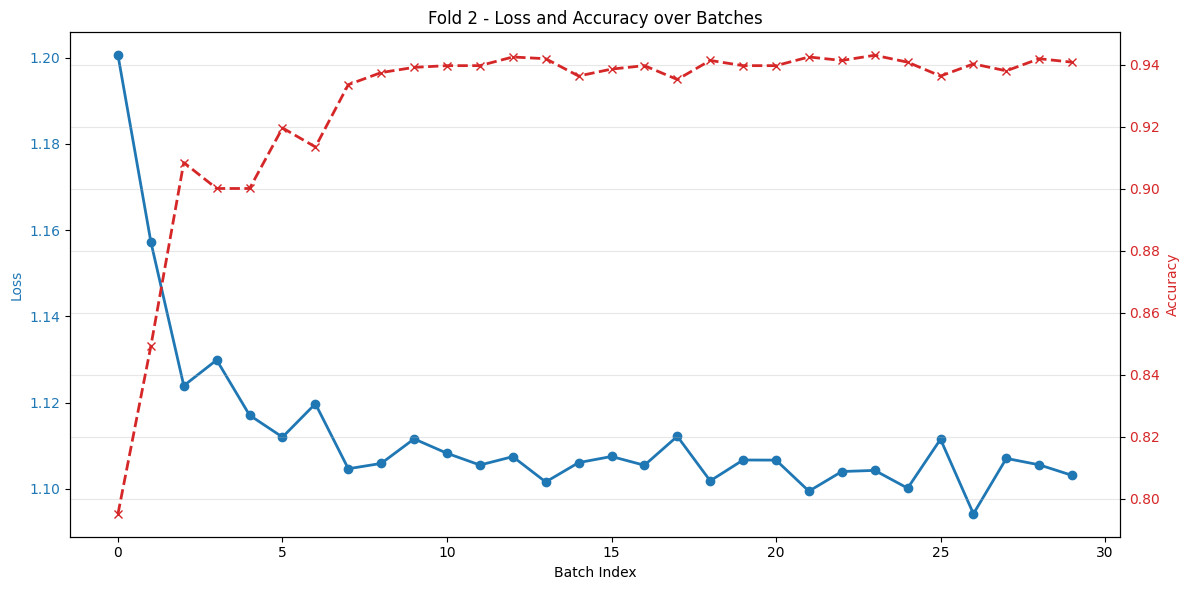

Fold 2 - Mean Loss: 1.112722, Std Loss: 0.019866
Fold 2 - Mean Accuracy: 0.926562, Std Accuracy: 0.031199


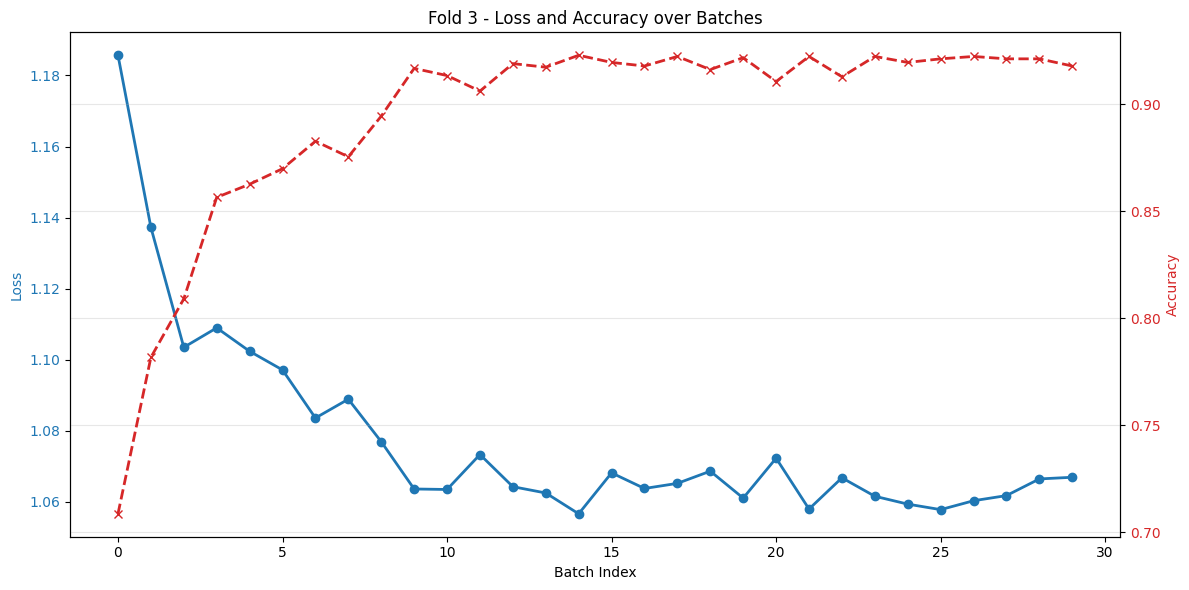

Fold 3 - Mean Loss: 1.077569, Std Loss: 0.027318
Fold 3 - Mean Accuracy: 0.894289, Std Accuracy: 0.048462


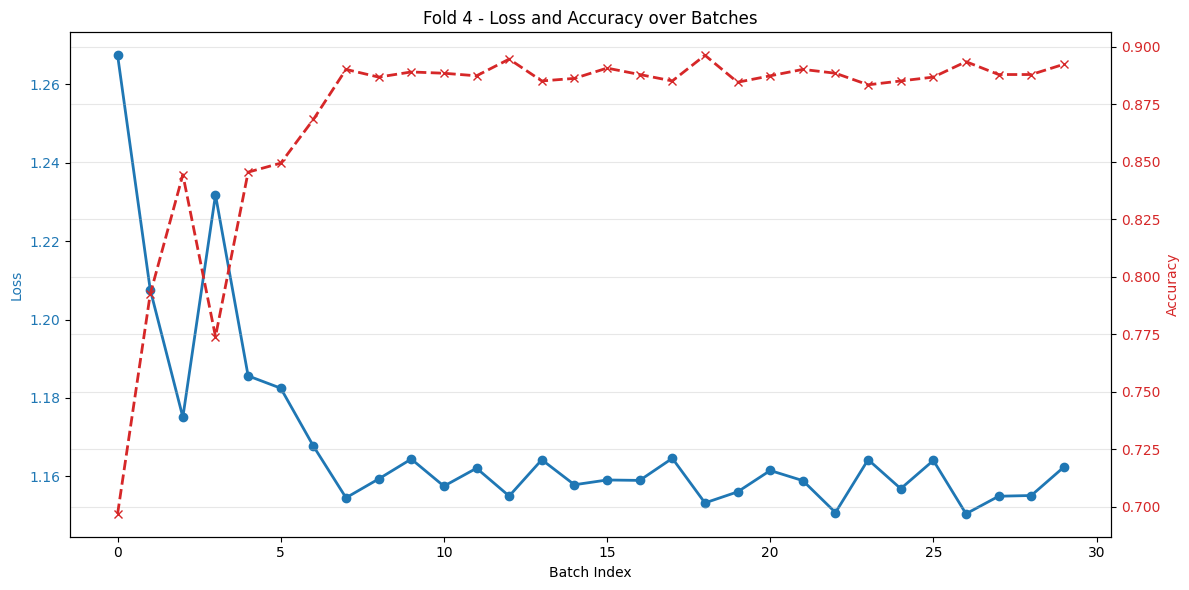

Fold 4 - Mean Loss: 1.168789, Std Loss: 0.024881
Fold 4 - Mean Accuracy: 0.870145, Std Accuracy: 0.042780


In [19]:
## subplot de todas as metricas juntas para cada fold
N_fold = 5
criterio = nn.CrossEntropyLoss()
for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    
    losses = []
    accuracies = []
    
    for j in range(len(df1_pred)):
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        
        # Calculate loss
        loss = criterio(outputs_tensor, labels_tensor)/len(df1_pred)
        losses.append(loss.item())
        
        # Calculate accuracy
        accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
        accuracies.append(accuracy)
    
    # Create subplots for loss and accuracy
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color = 'tab:blue'
    ax1.set_xlabel('Batch Index')
    ax1.set_ylabel('Loss', color=color)
    ax1.plot(losses, marker='o', linestyle='-', linewidth=2, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Accuracy', color=color)  # we already handled the x-label with ax1
    ax2.plot(accuracies, marker='x', linestyle='--', linewidth=2, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title(f'Fold {i} - Loss and Accuracy over Batches')
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Fold {i} - Mean Loss: {np.mean(losses):.6f}, Std Loss: {np.std(losses):.6f}")
    print(f"Fold {i} - Mean Accuracy: {np.mean(accuracies):.6f}, Std Accuracy: {np.std(accuracies):.6f}")


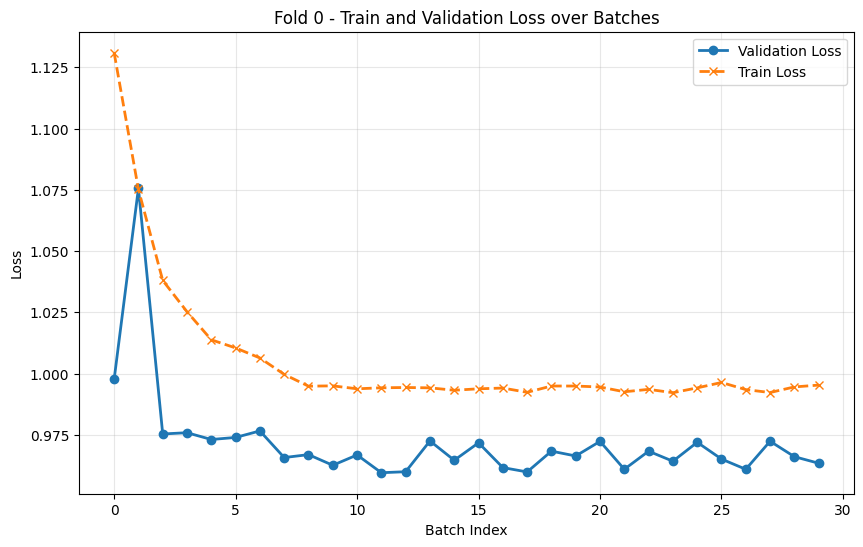

Fold 0 - Mean Validation Loss: 0.972007, Std Validation Loss: 0.020622


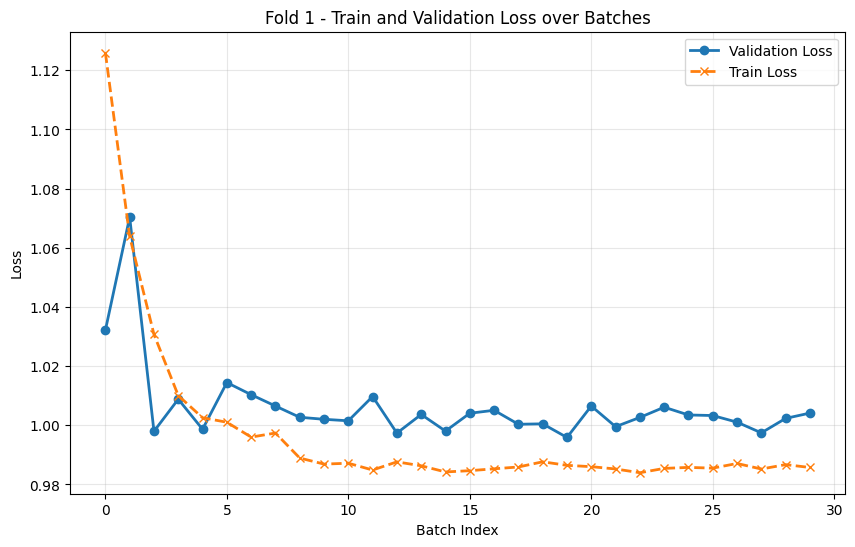

Fold 1 - Mean Validation Loss: 1.006222, Std Validation Loss: 0.013654


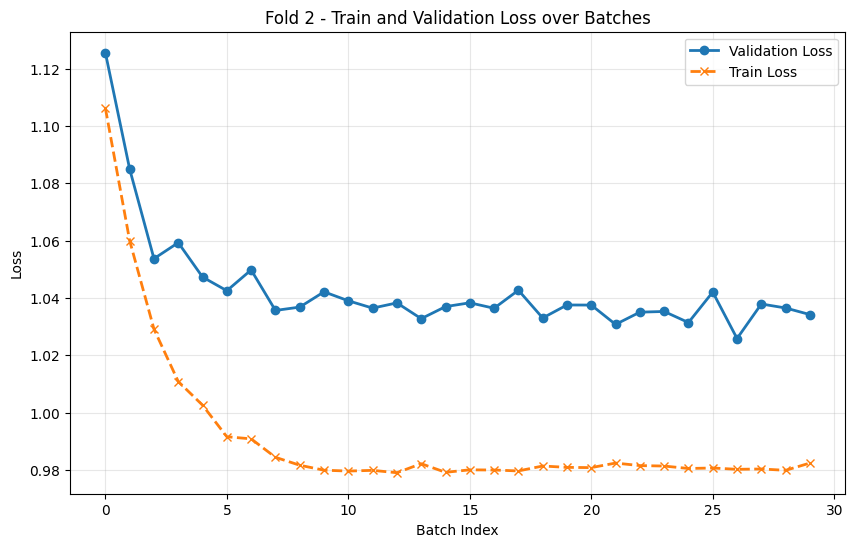

Fold 2 - Mean Validation Loss: 1.043177, Std Validation Loss: 0.018624


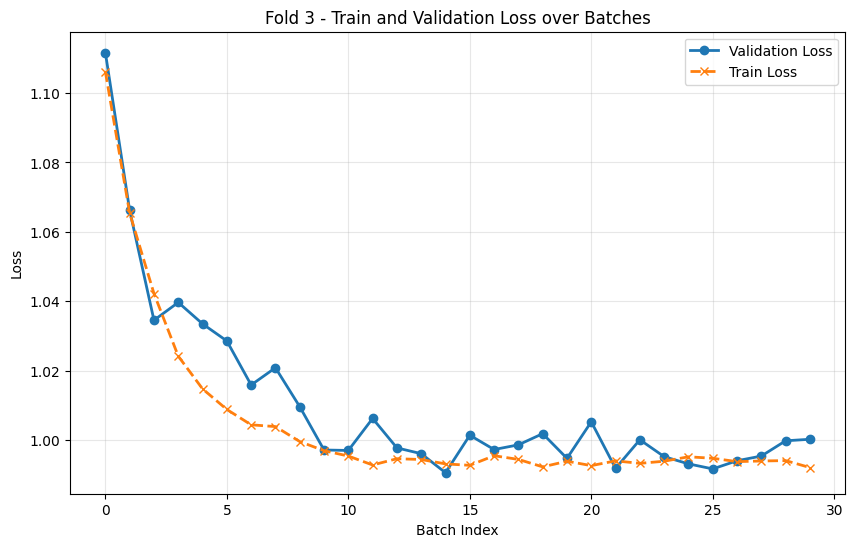

Fold 3 - Mean Validation Loss: 1.010221, Std Validation Loss: 0.025610


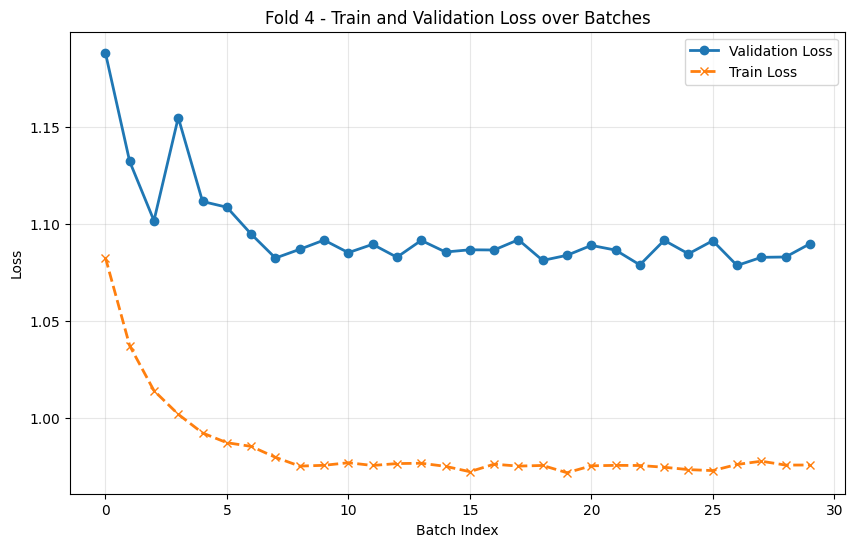

Fold 4 - Mean Validation Loss: 1.095740, Std Validation Loss: 0.023326


In [23]:
## Loss para treino e validação para cada fold
N_fold = 5
criterio = nn.CrossEntropyLoss()
for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_pred_train = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
    df1_true_train = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

    total_loss = []
    total_loss_train = []
    for j in range(len(df1_pred)):
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        
        loss = criterio(outputs_tensor, labels_tensor)/32
        total_loss.append(loss.item())
        outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
        labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
        loss_train = criterio(outputs_tensor_train, labels_tensor_train)/32
        total_loss_train.append(loss_train.item())
    
    # Create subplots for loss and accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Loss')
    plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Loss')
    plt.title(f'Fold {i} - Train and Validation Loss over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")

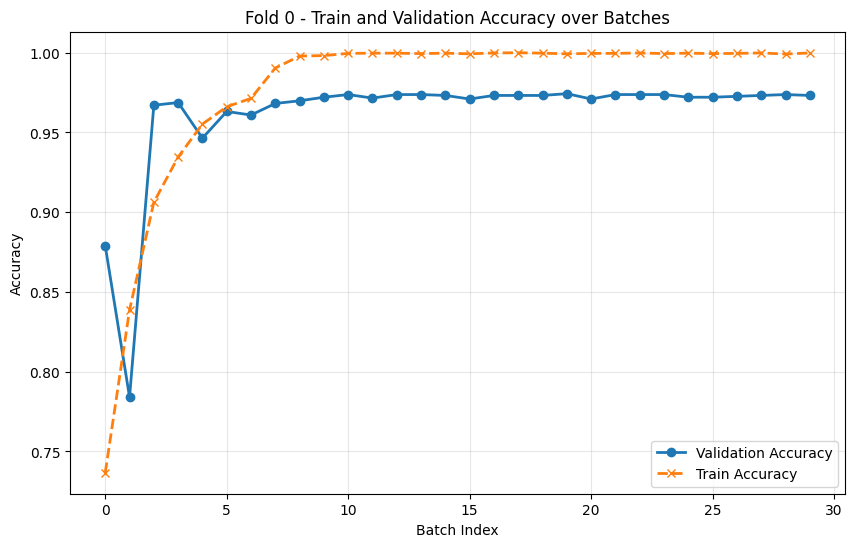

Fold 0 - Mean Validation Loss: 0.961328, Std Validation Loss: 0.037205


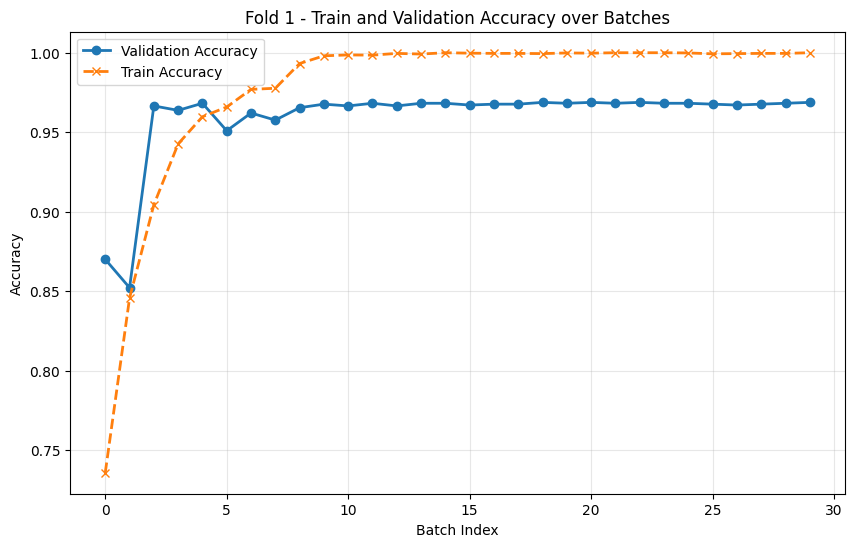

Fold 1 - Mean Validation Loss: 0.959412, Std Validation Loss: 0.026644


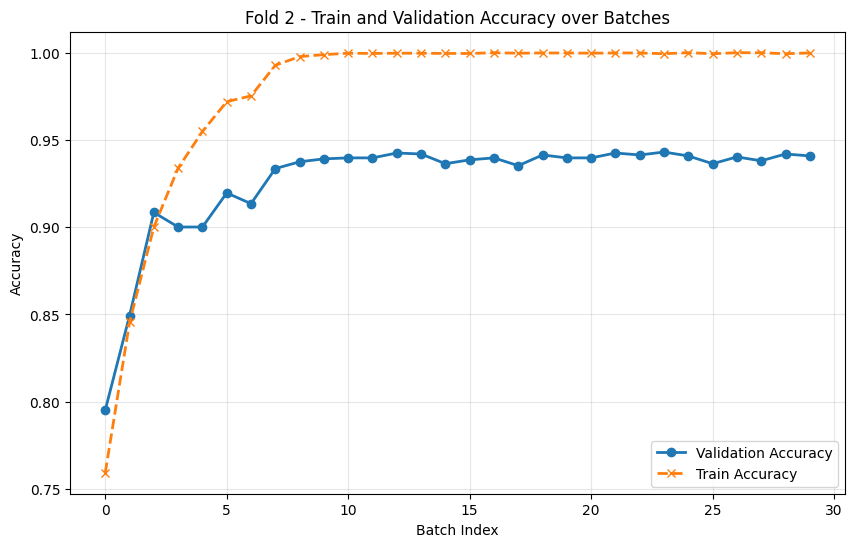

Fold 2 - Mean Validation Loss: 0.926562, Std Validation Loss: 0.031199


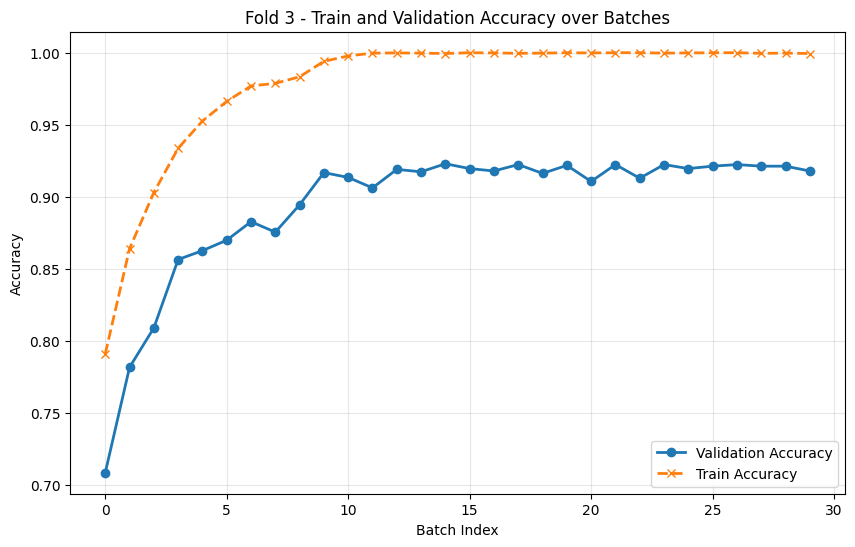

Fold 3 - Mean Validation Loss: 0.894289, Std Validation Loss: 0.048462


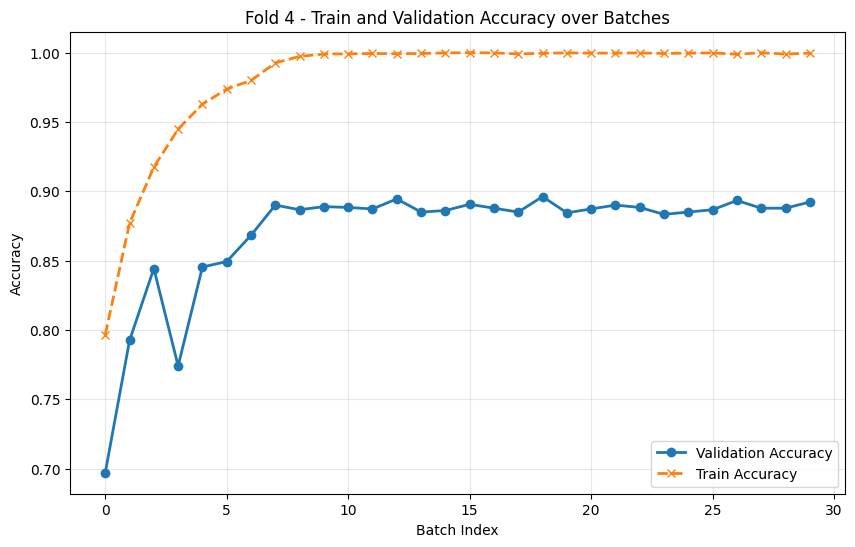

Fold 4 - Mean Validation Loss: 0.870145, Std Validation Loss: 0.042780


In [25]:
## Loss para treino e validação para cada fold
N_fold = 5
criterio = nn.CrossEntropyLoss()
for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
    df1_pred_train = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
    df1_true_train = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

    total_loss = []
    total_loss_train = []
    for j in range(len(df1_pred)):
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        
        accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
        total_loss.append(accuracy)
        outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
        labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
        accuracy_train = torch.sum(outputs_tensor_train == labels_tensor_train).item() / len(labels_tensor_train) / len(labels_tensor_train[-1])
        total_loss_train.append(accuracy_train)

    # Create subplots for loss and accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Accuracy')
    plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Accuracy')
    plt.title(f'Fold {i} - Train and Validation Accuracy over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")

In [55]:
def calc_metrics():
    ## Visao geral de todas as metricas juntas para cada fold com subplots
    N_fold = 5
    criterio = nn.CrossEntropyLoss()
    for i in range(N_fold):
        df1_pred = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_true = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_pred_train = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
        df1_true_train = np.float32(np.load(f'../saida_4000-augumented/saidas/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

        total_loss = []
        total_acc = []
        total_acc_train = []
        total_loss_train = []
        total_f1 = []
        total_f1_train = []
        total_recall = []
        total_recall_train = []
        total_precision = []
        total_precision_train = []
        for j in range(len(df1_pred)):
            outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
            labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
            
            accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
            total_acc.append(accuracy)
            outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
            labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
            accuracy_train = torch.sum(outputs_tensor_train == labels_tensor_train).item() / len(labels_tensor_train) / len(labels_tensor_train[-1])
            total_acc_train.append(accuracy_train)
        
            ## Loss calculo
            loss = criterio(outputs_tensor, labels_tensor)/32
            total_loss.append(loss.item())
            loss_train = criterio(outputs_tensor_train, labels_tensor_train)/32
            total_loss_train.append(loss_train.item())

            ## Recall e f1 score calculo
            # Convert predictions to binary labels using a threshold of 0.5
            predicted_labels = outputs_tensor
            true_labels = labels_tensor.int().numpy()
            precision = precision_score(true_labels, predicted_labels, average='micro')
            total_precision.append(precision)
            precision_train = precision_score(labels_tensor_train.int().numpy(), outputs_tensor_train, average='micro')
            total_precision_train.append(precision_train)

            ## Recall train valid
            recall = recall_score(true_labels, predicted_labels, average='micro')
            total_recall.append(recall)
            recall_train = recall_score(labels_tensor_train.int().numpy(), outputs_tensor_train, average='micro')
            total_recall_train.append(recall_train)

            ## F1 score train valid
            f1 = f1_score(true_labels, predicted_labels, average='micro')
            total_f1.append(f1)
            f1_train = f1_score(labels_tensor_train.int().numpy(), outputs_tensor_train, average='micro')
            total_f1_train.append(f1_train)
        # Create subplots for loss and accuracy
        plt.figure(figsize=(30, 20))
        plt.subplot(3, 3, 1)
        plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Loss')
        plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Loss')
        plt.title(f'Fold {i} - Train and Validation Loss over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)   
        plt.legend()
        plt.subplot(3, 3, 2)
        plt.plot(total_acc, marker='o', linestyle='-', linewidth=2, label='Validation Accuracy')
        plt.plot(total_acc_train, marker='x', linestyle='--', linewidth=2, label='Train Accuracy')
        plt.title(f'Fold {i} - Train and Validation Accuracy over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 3)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        ## Add subplot for Precision and Recall
        plt.subplot(3, 3, 4)
        plt.plot(total_precision, marker='o', linestyle='-', linewidth=2, label='Validation Precision')
        plt.plot(total_precision_train, marker='x', linestyle='--', linewidth=2, label='Train Precision')

        plt.title(f'Fold {i} - Train and Validation Precision and Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Precision / Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        ## Recall subplot
        plt.subplot(3, 3, 5)
        plt.plot(total_recall, marker='o', linestyle='-', linewidth=2, label='Validation Recall')
        plt.plot(total_recall_train, marker='x', linestyle='--', linewidth=2, label='Train Recall')
        plt.title(f'Fold {i} - Train    and Validation Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## F1 Score subplot
        plt.subplot(3, 3, 6)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.show()

        print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")
        print(f"Fold {i} - Mean Train Loss: {np.mean(total_loss_train):.6f}, Std Train Loss: {np.std(total_loss_train):.6f}")
        print(f"Fold {i} - Mean Validation Accuracy: {np.mean(total_acc):.6f}, Std Validation Accuracy: {np.std(total_acc):.6f}")
        print(f"Fold {i} - Mean Train Accuracy: {np.mean(total_acc_train):.6f}, Std Train Accuracy: {np.std(total_acc_train):.6f}")
        print(f"Fold {i} - Mean Validation Precision: {np.mean(total_precision):.6f}, Std Validation Precision: {np.std(total_precision):.6f}")
        print(f"Fold {i} - Mean Train Precision: {np.mean(total_precision_train):.6f}, Std Train Precision: {np.std(total_precision_train):.6f}")
        print(f"Fold {i} - Mean Validation Recall: {np.mean(total_recall):.6f}, Std Validation Recall: {np.std(total_recall):.6f}")
        print(f"Fold {i} - Mean Train Recall: {np.mean(total_recall_train):.6f}, Std Train Recall: {np.std(total_recall_train):.6f}")
        print(f"Fold {i} - Mean Validation F1 Score: {np.mean(total_f1):.6f}, Std Validation F1 Score: {np.std(total_f1):.6f}")
        print(f"Fold {i} - Mean Train F1 Score: {np.mean(total_f1_train):.6f}, Std Train F1 Score: {np.std(total_f1_train):.6f}")

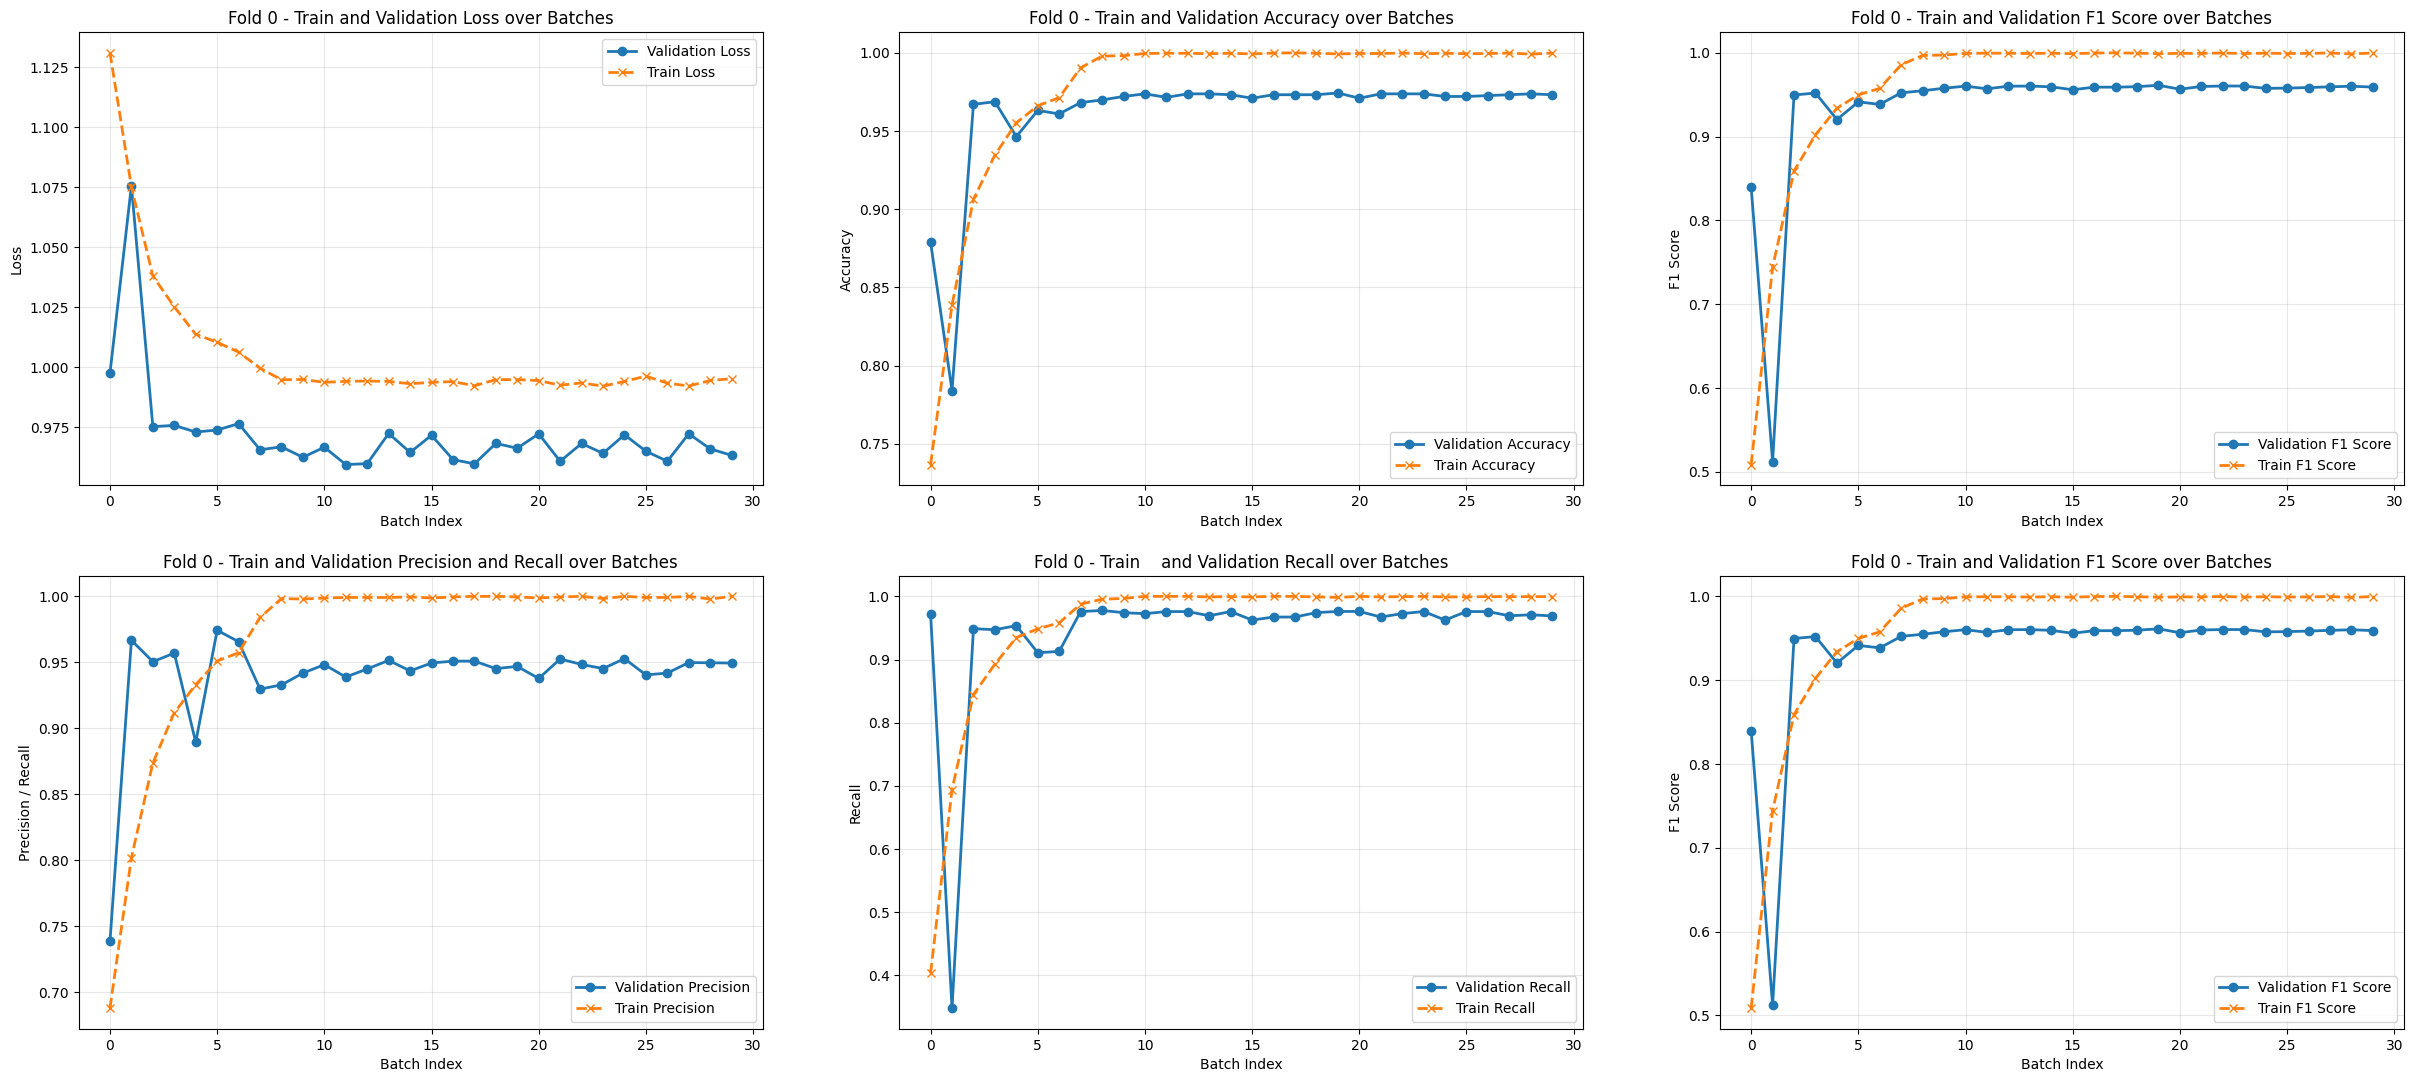

Fold 0 - Mean Validation Loss: 0.972007, Std Validation Loss: 0.020622
Fold 0 - Mean Train Loss: 1.005603, Std Train Loss: 0.028917
Fold 0 - Mean Validation Accuracy: 0.961328, Std Validation Accuracy: 0.037205
Fold 0 - Mean Train Accuracy: 0.976269, Std Train Accuracy: 0.056447
Fold 0 - Mean Validation Precision: 0.939517, Std Validation Precision: 0.039816
Fold 0 - Mean Train Precision: 0.969466, Std Train Precision: 0.068637
Fold 0 - Mean Validation Recall: 0.945167, Std Validation Recall: 0.112060
Fold 0 - Mean Train Recall: 0.954901, Std Train Recall: 0.120137
Fold 0 - Mean Validation F1 Score: 0.936698, Std Validation F1 Score: 0.081978
Fold 0 - Mean Train F1 Score: 0.960805, Std Train F1 Score: 0.099875


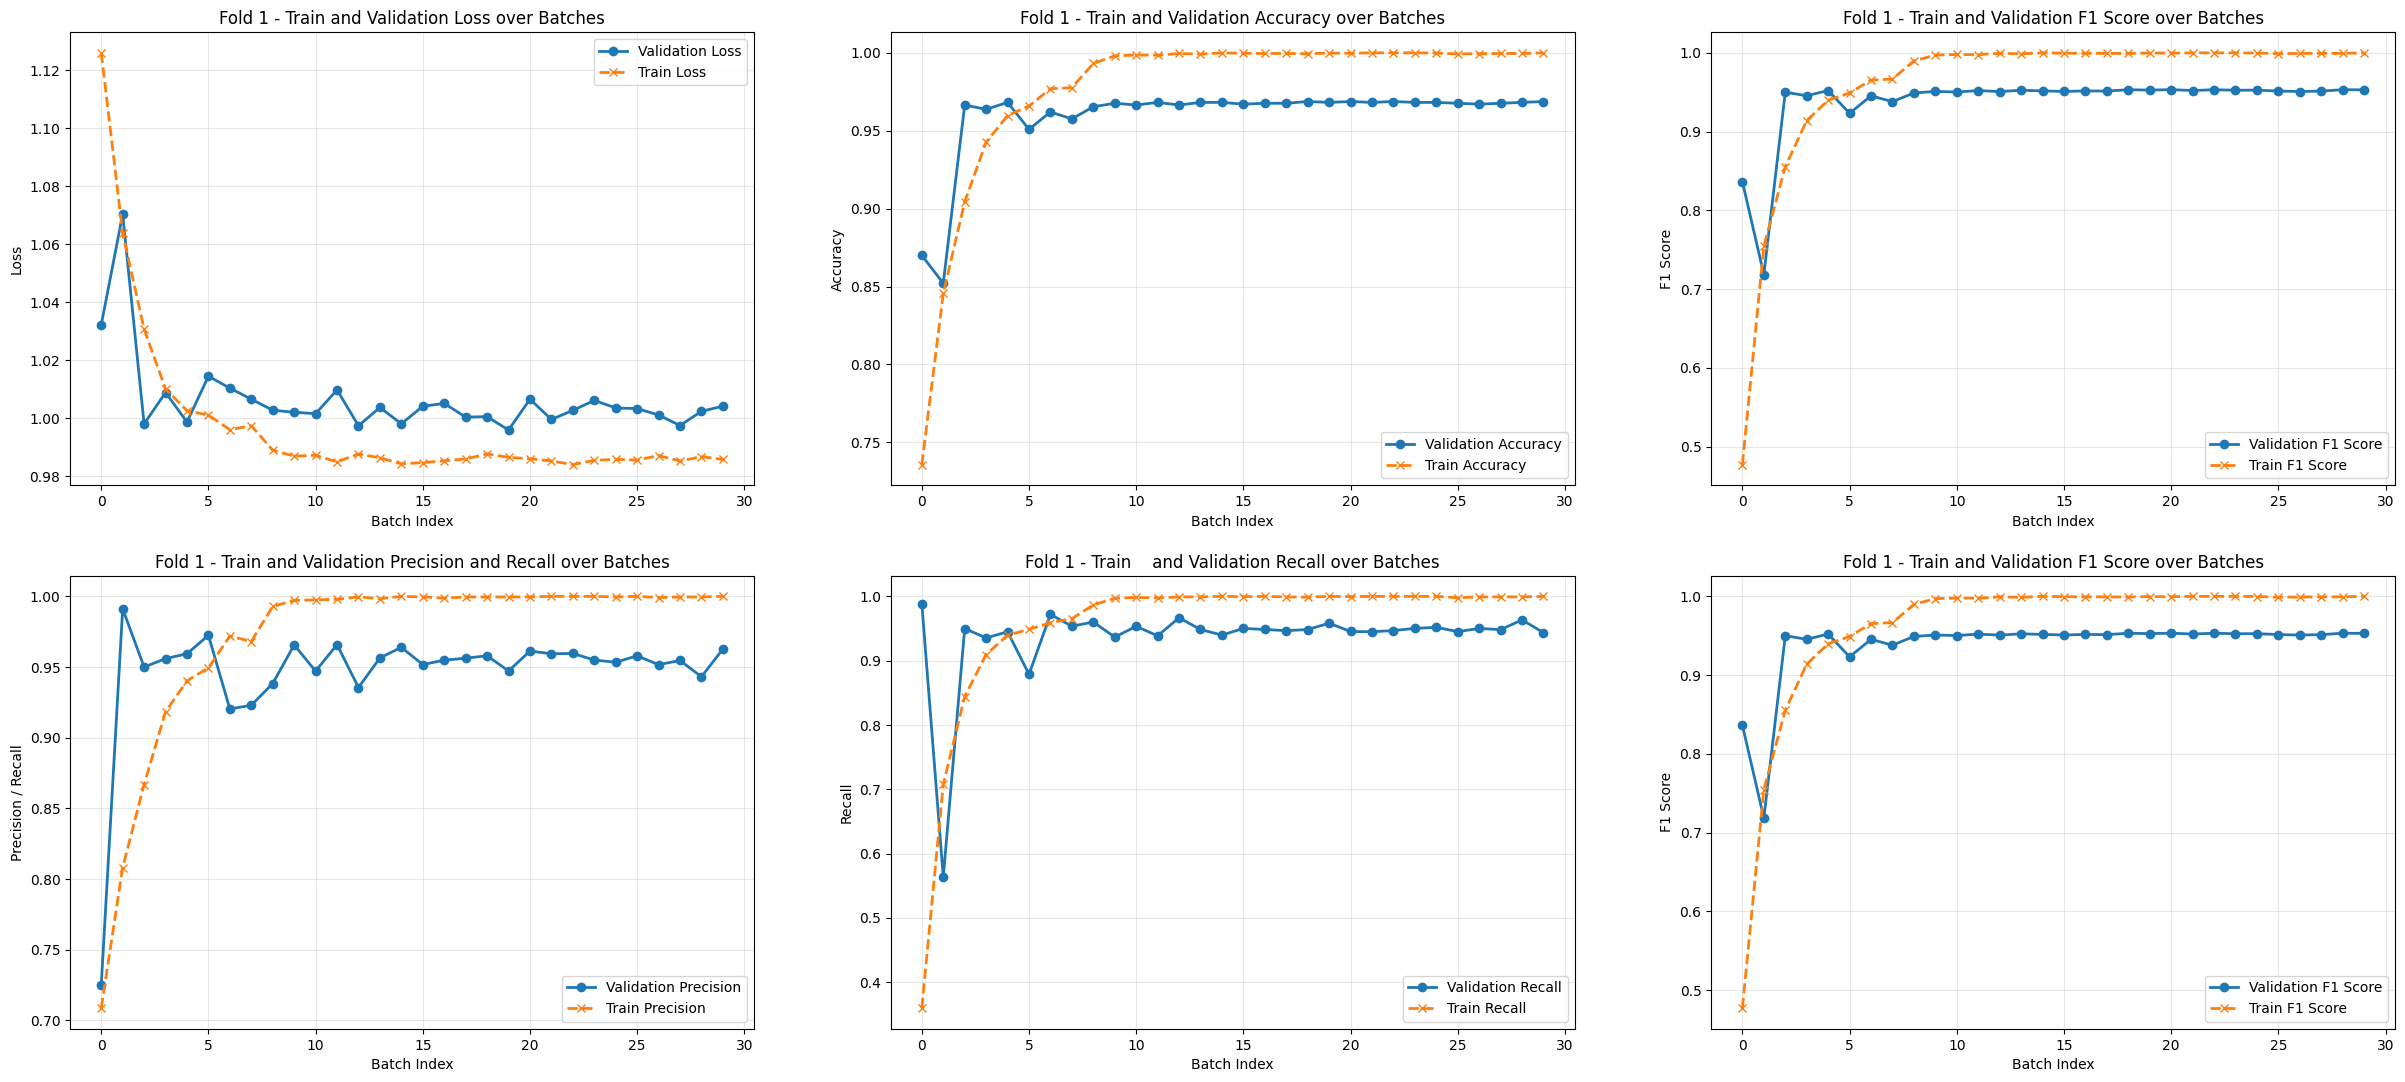

Fold 1 - Mean Validation Loss: 1.006222, Std Validation Loss: 0.013654
Fold 1 - Mean Train Loss: 0.997338, Std Train Loss: 0.028941
Fold 1 - Mean Validation Accuracy: 0.959412, Std Validation Accuracy: 0.026644
Fold 1 - Mean Train Accuracy: 0.976370, Std Train Accuracy: 0.055763
Fold 1 - Mean Validation Precision: 0.946544, Std Validation Precision: 0.043278
Fold 1 - Mean Train Precision: 0.970311, Std Train Precision: 0.065260
Fold 1 - Mean Validation Recall: 0.935724, Std Validation Recall: 0.071153
Fold 1 - Mean Train Recall: 0.953463, Std Train Recall: 0.125499
Fold 1 - Mean Validation F1 Score: 0.938329, Std Validation F1 Score: 0.046009
Fold 1 - Mean Train F1 Score: 0.959868, Std Train F1 Score: 0.103667


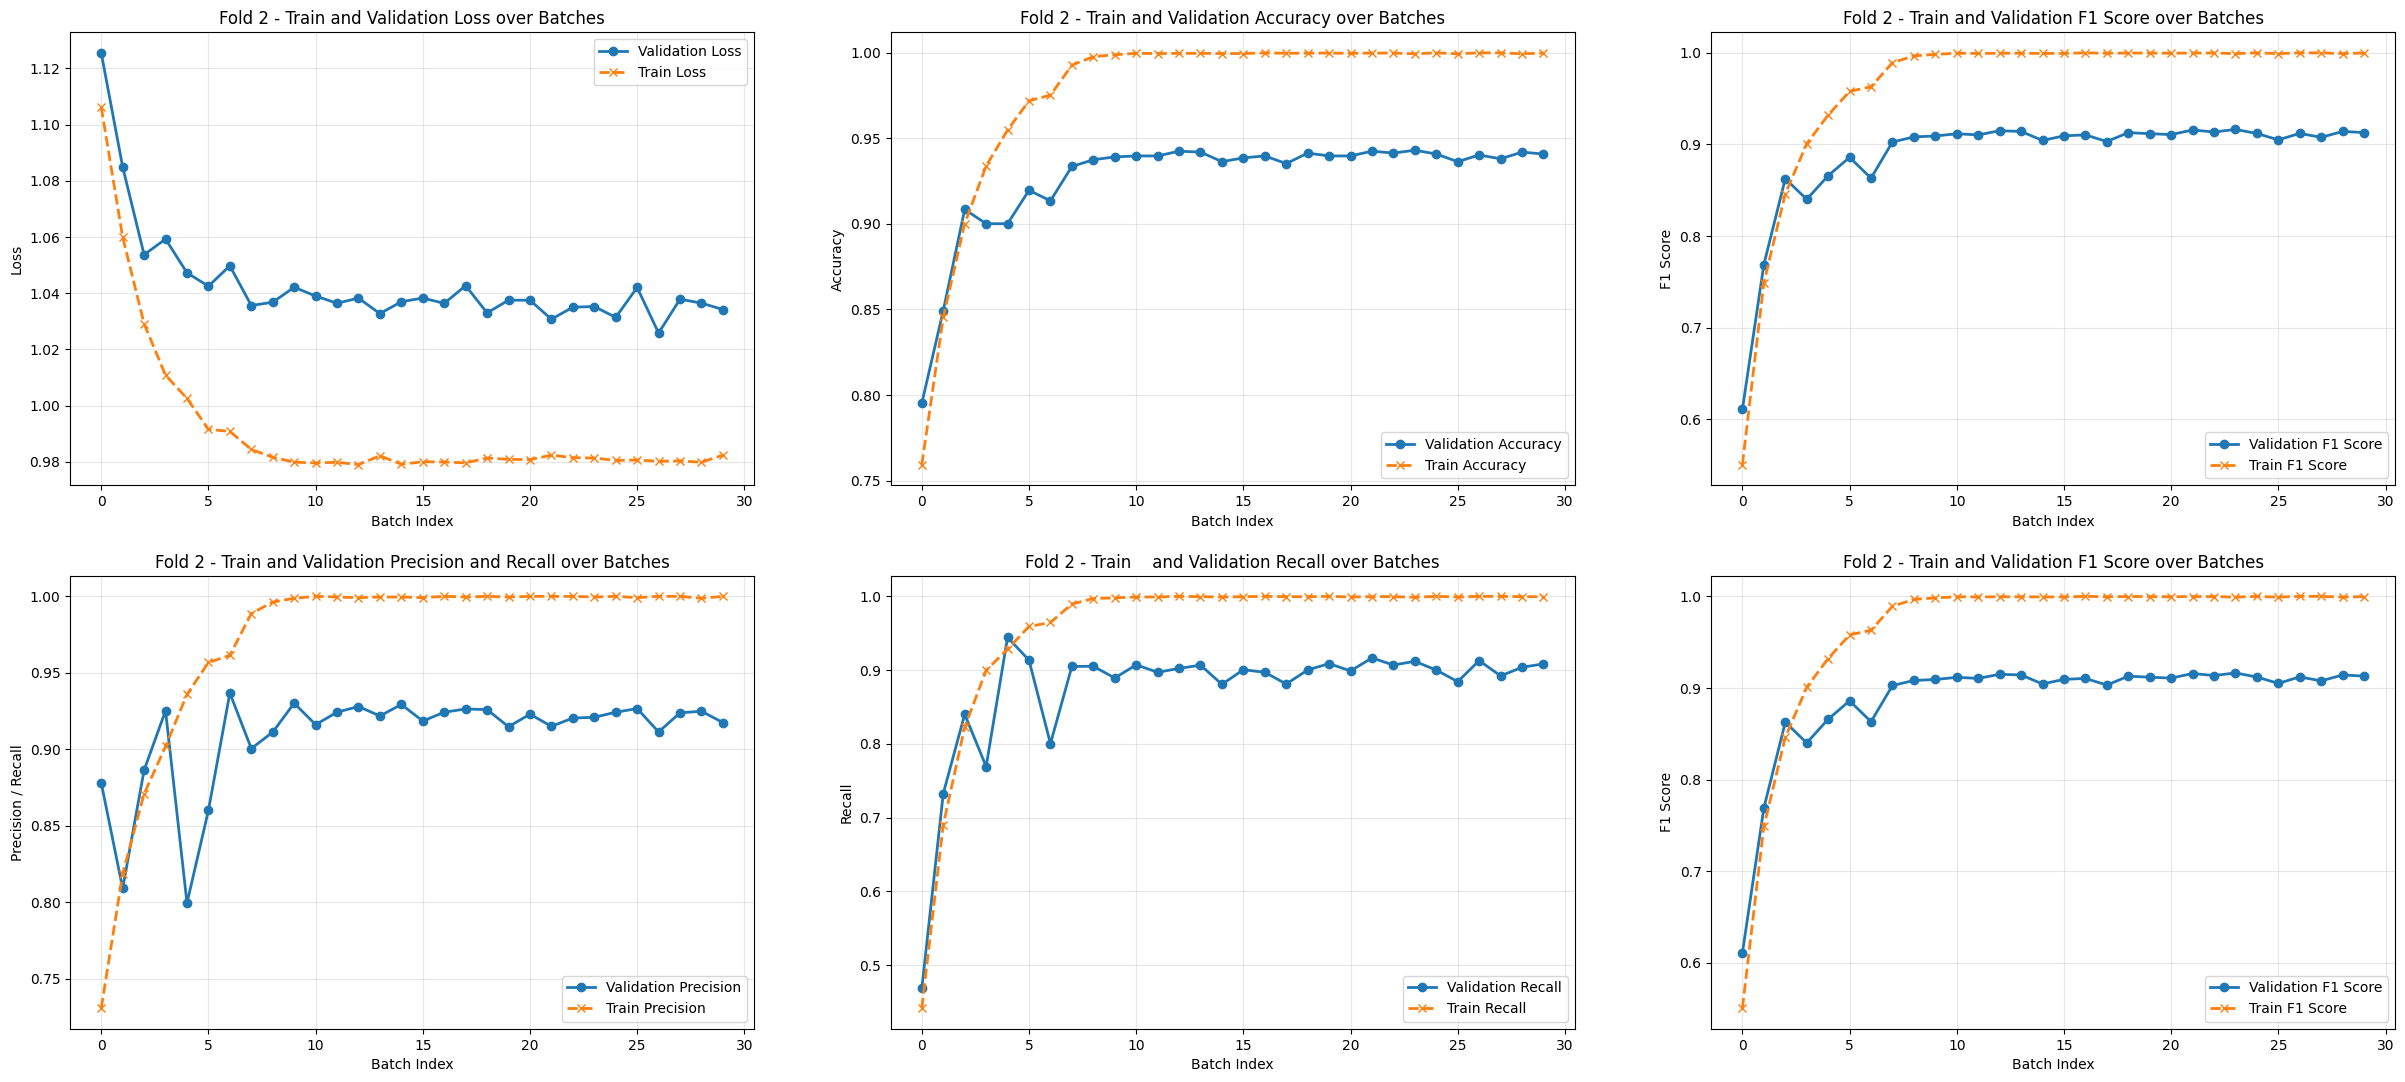

Fold 2 - Mean Validation Loss: 1.043177, Std Validation Loss: 0.018624
Fold 2 - Mean Train Loss: 0.991621, Std Train Loss: 0.027351
Fold 2 - Mean Validation Accuracy: 0.926562, Std Validation Accuracy: 0.031199
Fold 2 - Mean Train Accuracy: 0.977509, Std Train Accuracy: 0.053070
Fold 2 - Mean Validation Precision: 0.909121, Std Validation Precision: 0.032242
Fold 2 - Mean Train Precision: 0.971784, Std Train Precision: 0.062051
Fold 2 - Mean Validation Recall: 0.872833, Std Validation Recall: 0.087022
Fold 2 - Mean Train Recall: 0.956068, Std Train Recall: 0.115429
Fold 2 - Mean Validation F1 Score: 0.888037, Std Validation F1 Score: 0.059767
Fold 2 - Mean Train F1 Score: 0.962531, Std Train F1 Score: 0.093894


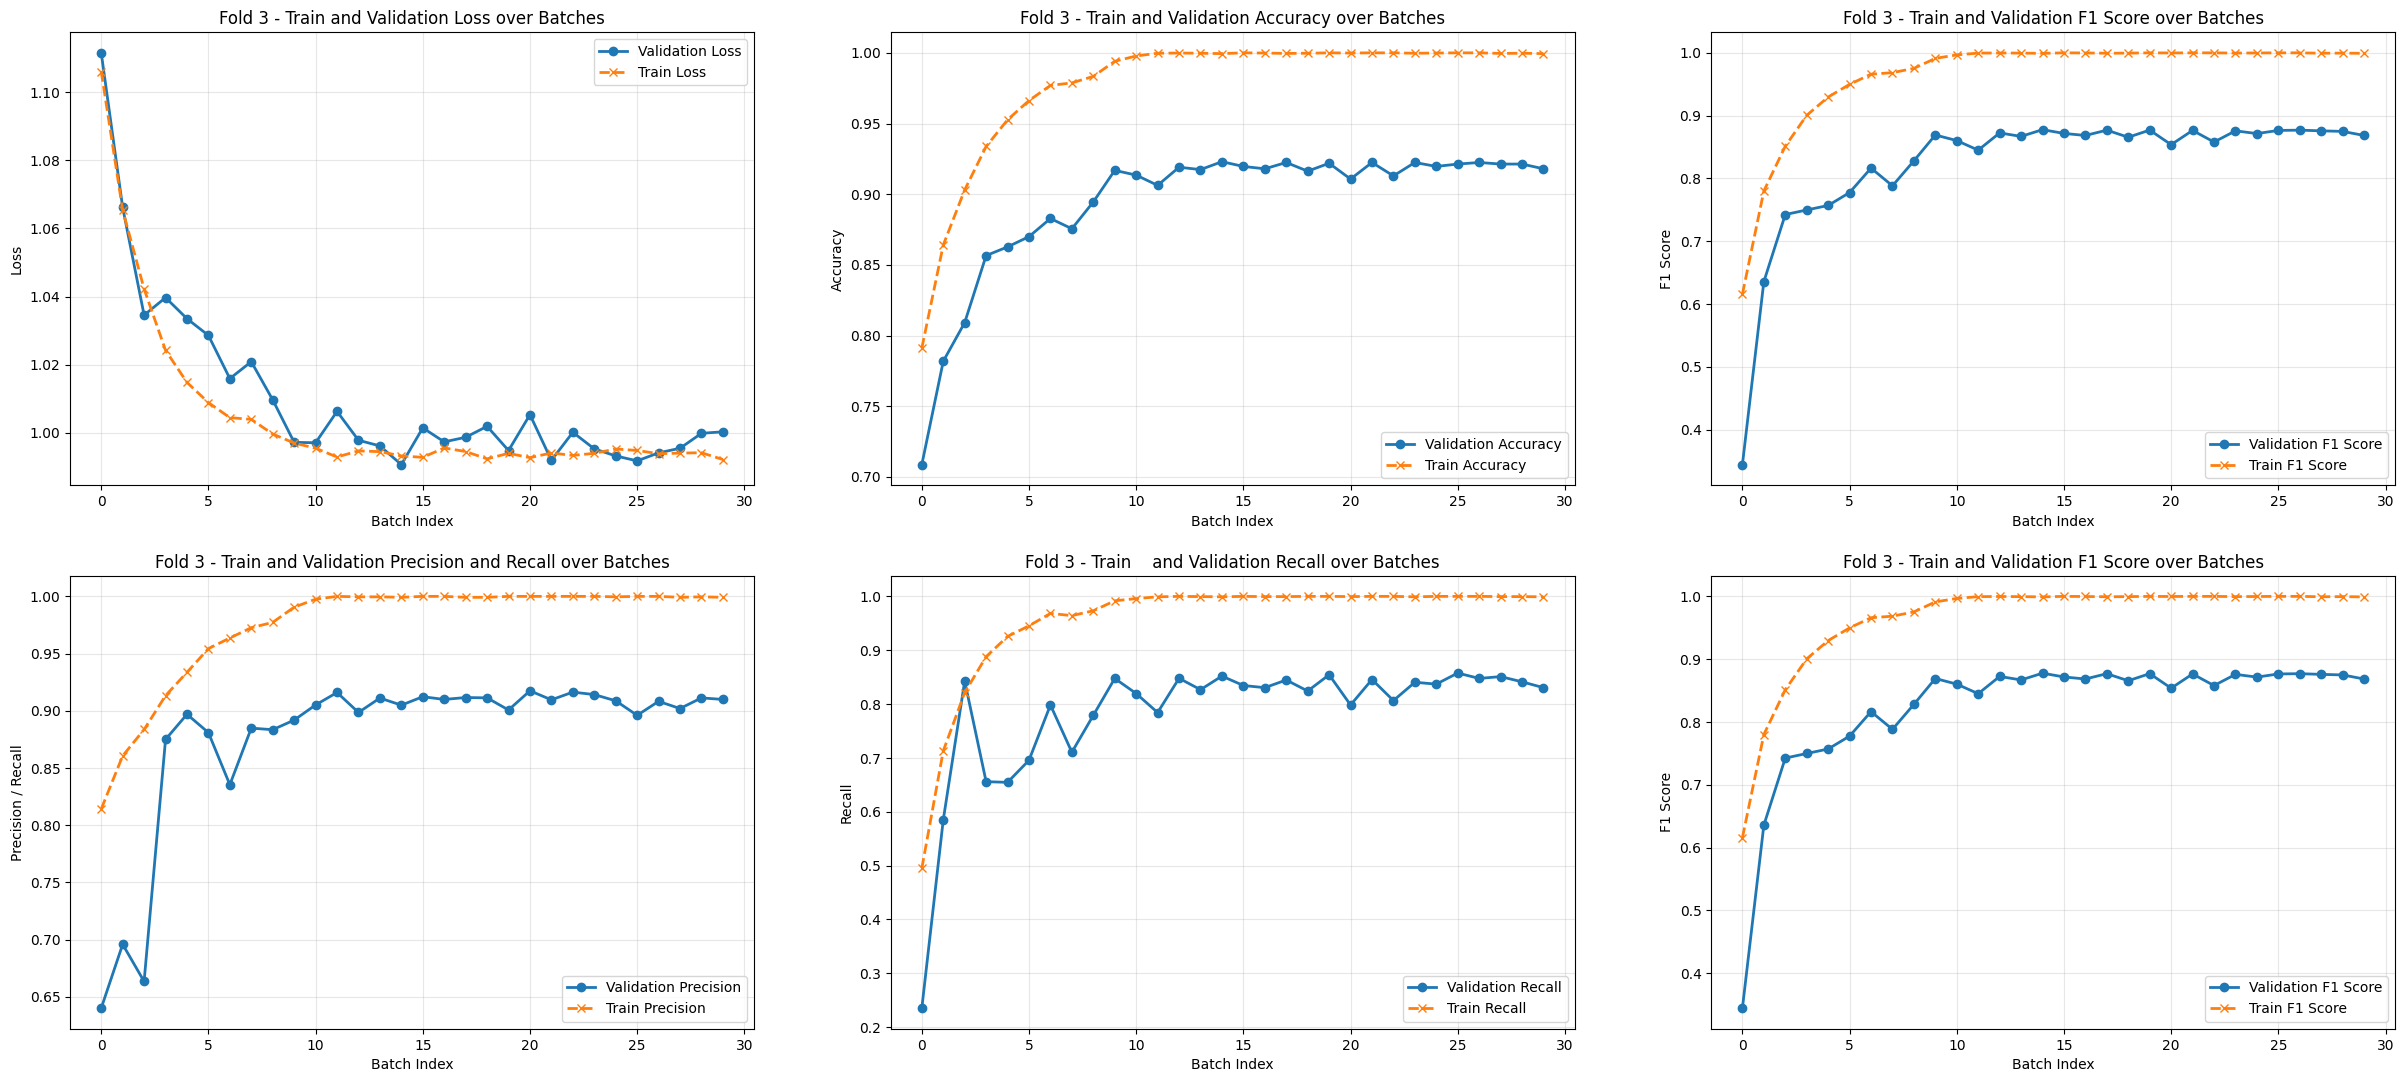

Fold 3 - Mean Validation Loss: 1.010221, Std Validation Loss: 0.025610
Fold 3 - Mean Train Loss: 1.004804, Std Train Loss: 0.024707
Fold 3 - Mean Validation Accuracy: 0.894289, Std Validation Accuracy: 0.048462
Fold 3 - Mean Train Accuracy: 0.977926, Std Train Accuracy: 0.046896
Fold 3 - Mean Validation Precision: 0.877459, Std Validation Precision: 0.072518
Fold 3 - Mean Train Precision: 0.975184, Std Train Precision: 0.046804
Fold 3 - Mean Validation Recall: 0.782658, Std Validation Recall: 0.122647
Fold 3 - Mean Train Recall: 0.955869, Std Train Recall: 0.105664
Fold 3 - Mean Validation F1 Score: 0.823259, Std Validation F1 Score: 0.105006
Fold 3 - Mean Train F1 Score: 0.963954, Std Train F1 Score: 0.081538


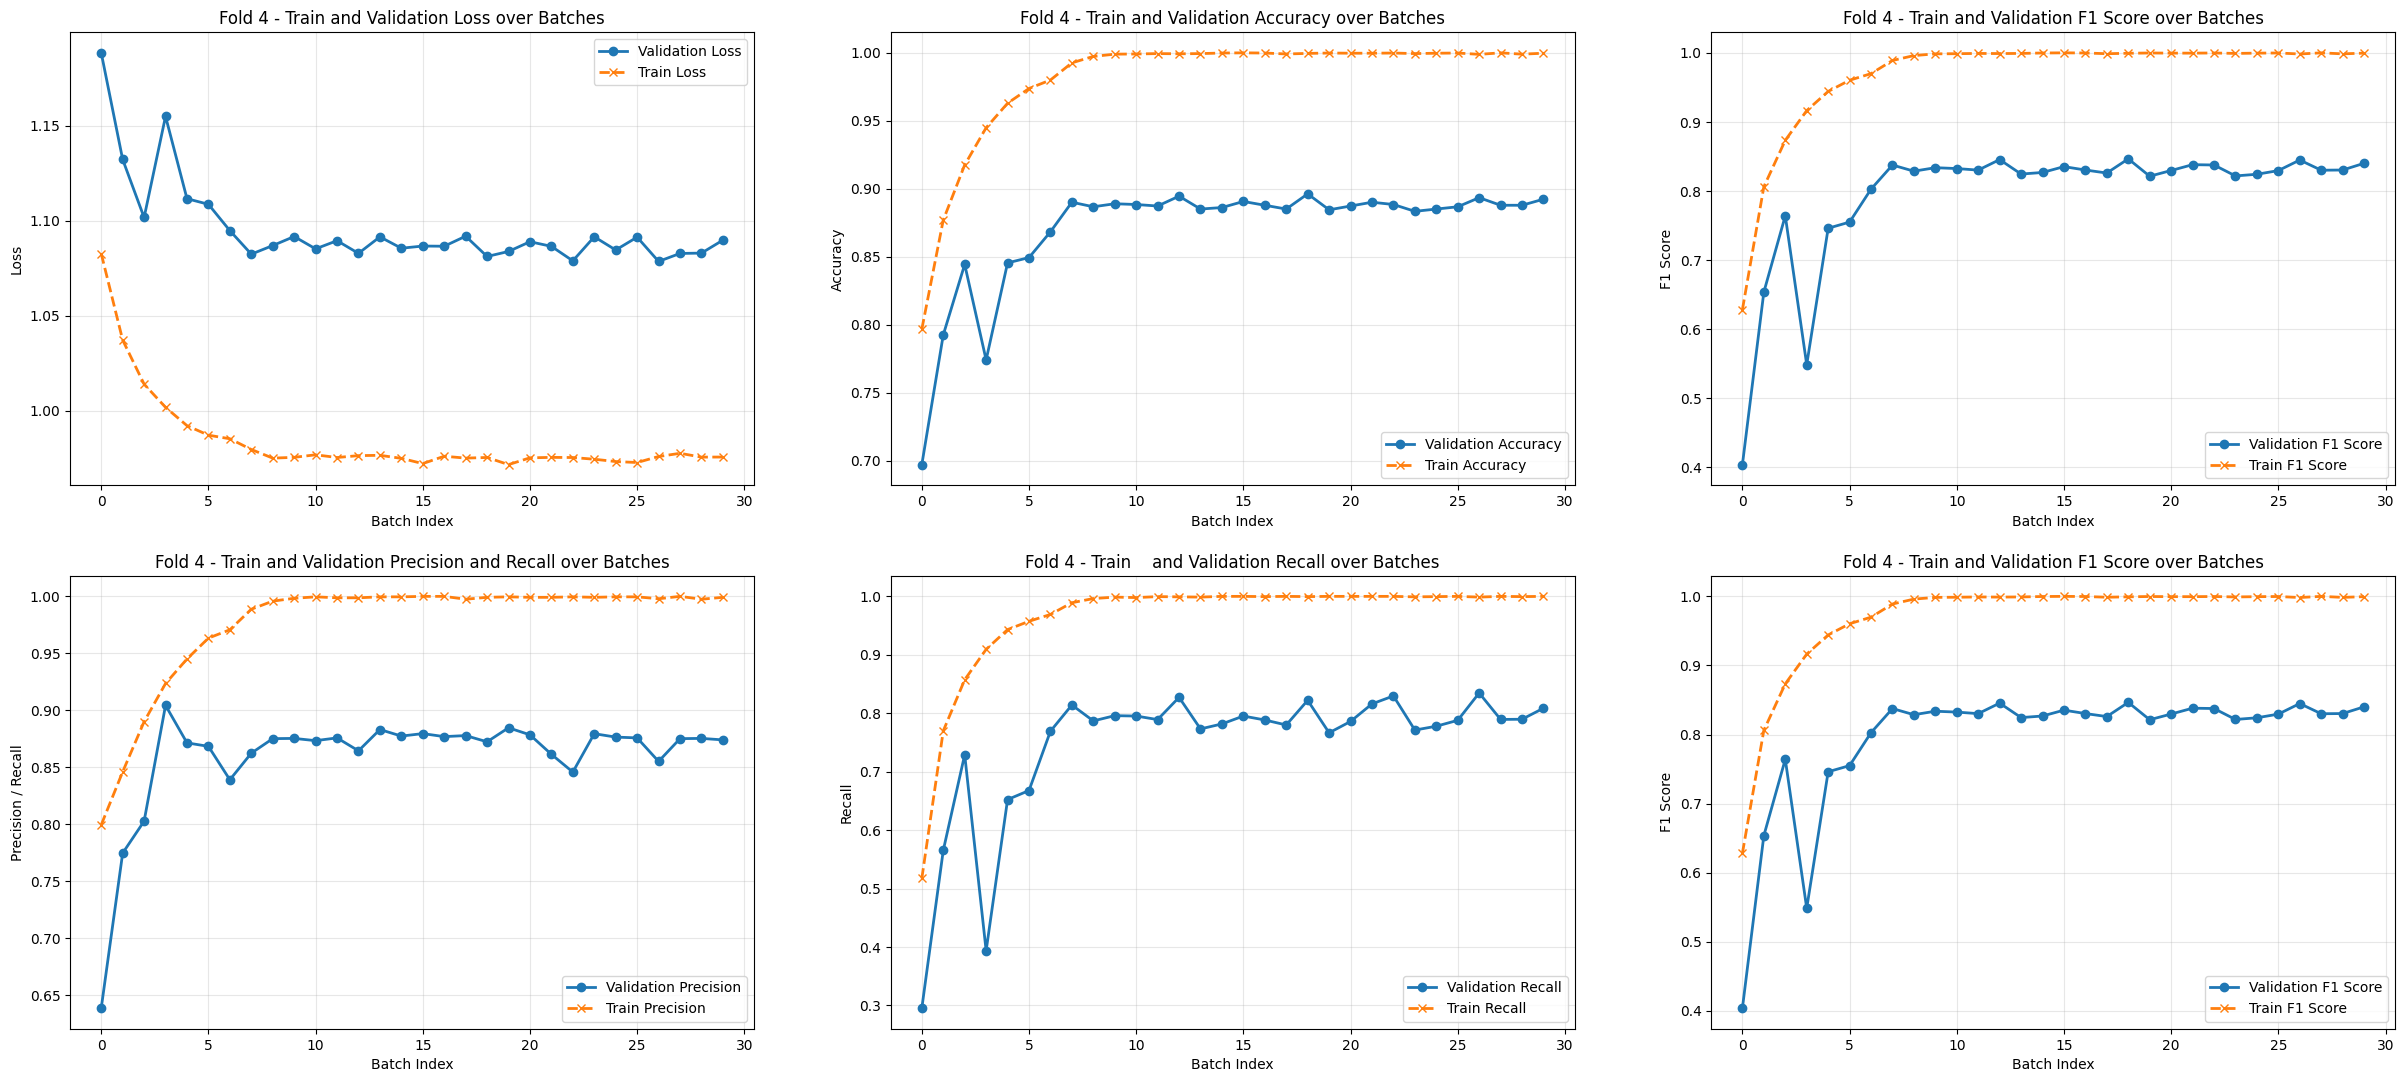

Fold 4 - Mean Validation Loss: 1.095740, Std Validation Loss: 0.023326
Fold 4 - Mean Train Loss: 0.984441, Std Train Loss: 0.022831
Fold 4 - Mean Validation Accuracy: 0.870145, Std Validation Accuracy: 0.042780
Fold 4 - Mean Train Accuracy: 0.981111, Std Train Accuracy: 0.044031
Fold 4 - Mean Validation Precision: 0.859257, Std Validation Precision: 0.047502
Fold 4 - Mean Train Precision: 0.976827, Std Train Precision: 0.048656
Fold 4 - Mean Validation Recall: 0.745953, Std Validation Recall: 0.121302
Fold 4 - Mean Train Recall: 0.963302, Std Train Recall: 0.096660
Fold 4 - Mean Validation F1 Score: 0.793991, Std Validation F1 Score: 0.095221
Fold 4 - Mean Train F1 Score: 0.968983, Std Train F1 Score: 0.076529


In [56]:
calc_metrics()

## Testes 

ECGClassifierResnet(
  (base_model): ResNet(
    (conv1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [19]:
## Funções Otimizadas para Leitura de CSV e Carregamento de Imagens

import os
import psutil
from pathlib import Path

def explore_csv(csv_path, max_rows=5):
    """
    Explora arquivo CSV fornecendo informações detalhadas.

    Parâmetros:
        csv_path (str): Caminho do arquivo CSV
        max_rows (int): Número de linhas para exibir

    Retorna:
        pd.DataFrame: Dados carregados
    """
    print("="*80)
    print("📋 EXPLORAÇÃO DO ARQUIVO CSV")
    print("="*80)

    # Verificar se arquivo existe
    if not os.path.exists(csv_path):
        print(f"❌ ERRO: Arquivo não encontrado: {csv_path}")
        return None

    print(f"✓ Arquivo encontrado: {csv_path}")
    print(f"  Tamanho do arquivo: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")

    try:
        # Ler CSV
        print("\n📖 Lendo arquivo CSV...")
        data = pd.read_csv(csv_path)

        print(f"✓ CSV lido com sucesso!")
        print(f"  Shape: {data.shape} (linhas, colunas)")
        print(f"  Colunas: {list(data.columns)}")
        print(f"  Tipos de dados:\n{data.dtypes}\n")

        # Verificar valores nulos
        print("📊 Valores Nulos:")
        null_counts = data.isnull().sum()
        if null_counts.sum() == 0:
            print("  ✓ Nenhum valor nulo encontrado!")
        else:
            print(f"  ⚠ Valores nulos encontrados:\n{null_counts}\n")

        # Primeiras linhas
        print(f"📄 Primeiras {max_rows} linhas:")
        print(data.head(max_rows).to_string())

        # Estatísticas
        print(f"\n📈 Estatísticas básicas:")
        print(f"  Total de amostras: {len(data)}")
        if data.shape[1] >= 2:
            label_col = data.columns[1]
            print(f"  Distribuição de labels ({label_col}):")
            print(data[label_col].value_counts().to_string())

        print("="*80)
        return data

    except Exception as e:
        print(f"❌ ERRO ao ler CSV: {e}")
        return None


def validate_and_load_images(data, image_path_prefix, n_samples=None, max_errors=10):
    """
    Valida e carrega imagens com tratamento robusto de erros.

    Parâmetros:
        data (pd.DataFrame): DataFrame com caminhos das imagens
        image_path_prefix (str): Prefixo do caminho das imagens
        n_samples (int): Número de amostras a carregar (None = todas)
        max_errors (int): Máximo de erros antes de parar

    Retorna:
        tuple: (img_dataset, data_valid, error_count)
    """
    print("\n" + "="*80)
    print("🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS")
    print("="*80)

    # Preparar dados
    if n_samples is not None:
        data_sample = data.sample(n=min(n_samples, len(data)), random_state=42).reset_index(drop=True)
    else:
        data_sample = data.reset_index(drop=True)

    print(f"\n📌 Configuração:")
    print(f"  Amostras a processar: {len(data_sample)}")
    print(f"  Prefixo de caminho: {image_path_prefix}")
    print(f"  Máximo de erros permitidos: {max_errors}")

    # Verificar memória disponível
    memory_info = psutil.virtual_memory()
    print(f"\n💾 Memória disponível: {memory_info.available / (1024**3):.2f} GB")
    estimated_memory = (len(data_sample) * 3 * 256 * 256 * 1) / (1024**3)
    print(f"  Memória estimada para imagens: {estimated_memory:.2f} GB")

    if estimated_memory > memory_info.available * 0.8:
        print(f"  ⚠ AVISO: Uso de memória pode ser alto!")

    # Preparar array
    img_dataset = np.zeros((len(data_sample),3,256, 256), dtype=np.uint8)
    error_indices = []
    error_count = 0

    print(f"\n🔄 Carregando imagens...")

    for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Carregando imagens'):
        try:
            img_path = row.iloc[0]  # Primeira coluna = caminho
            full_path = os.path.join(image_path_prefix, img_path)

            # Verificar se arquivo existe
            if not os.path.exists(full_path):
                raise FileNotFoundError(f"Imagem não encontrada: {full_path}")

            # Carregar imagem
            img = treat_image_PIL(img_path, type_return=3)

            img_dataset[idx] = img

        except Exception as e:
            error_count += 1
            error_indices.append(idx)

            if error_count == 1:
                print(f"\n⚠ Erros encontrados durante carregamento:")

            print(f"  Erro na amostra {idx}: {type(e).__name__}: {str(e)[:60]}")

            if error_count >= max_errors:
                print(f"\n❌ Máximo de {max_errors} erros atingido. Parando...")
                break

    # Remover amostras com erro
    if error_indices:
        print(f"\n🧹 Removendo {len(error_indices)} amostras com erro...")
        valid_indices = [i for i in range(len(data_sample)) if i not in error_indices]
        img_dataset = img_dataset[valid_indices]
        data_sample = data_sample.iloc[valid_indices].reset_index(drop=True)

    print("\n✅ Carregamento concluído!")
    print(f"  Imagens carregadas com sucesso: {len(img_dataset)}")
    print(f"  Imagens com erro: {error_count}")
    print(f"  Shape final: {img_dataset.shape}")
    print("="*80)

    return img_dataset, data_sample, error_count


def get_image_statistics(img_dataset):
    """Calcula estatísticas das imagens carregadas."""
    print("\n" + "="*80)
    print("📊 ESTATÍSTICAS DAS IMAGENS")
    print("="*80)

    print(f"Shape: {img_dataset.shape}")
    print(f"Tipo de dado: {img_dataset.dtype}")
    print(f"Min: {img_dataset.min()}")
    print(f"Max: {img_dataset.max()}")
    print(f"Média: {img_dataset.mean():.2f}")
    print(f"Std: {img_dataset.std():.2f}")
    print(f"Memória total: {img_dataset.nbytes / (1024**2):.2f} MB")
    print("="*80)


In [ ]:
## Load images to test

FILE_PATH = "../../dataset/dataset_FA_Outros_PatientID.csv"
print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")

## concat file_path and file_path_aug and read both csvs and concatenate the dataframes

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = explore_csv(FILE_PATH, max_rows=10)


## CSV concat com data augumentation

print(f"\n📌 Após concatenação com data augmentation: {len(data)} amostras") 
1